Load and Anonymized Dataset

In [ ]:
import pandas as pd
import hashlib

# Hash function
def hash_value(value):
    if pd.isna(value):
        return value
    return hashlib.sha256(str(value).encode()).hexdigest()

# Load datasets
assessment = pd.read_csv("StudentAssessment.csv")
activity   = pd.read_csv("StudentActivity.csv")
info       = pd.read_csv("StudentInfo.csv")

print("Loaded datasets")

if "reg_no" in assessment.columns:
    assessment["reg_no"] = assessment["reg_no"].apply(hash_value)

if "reg_no" in activity.columns:
    activity["reg_no"] = activity["reg_no"].apply(hash_value)

if "reg_no" in info.columns:
    info["reg_no"] = info["reg_no"].apply(hash_value)

if "email" in info.columns:
    info["email"] = info["email"].apply(hash_value)

# Save Anonymized datasets
assessment.to_csv("StudentAssessment_anonymized.csv", index=False)
activity.to_csv("StudentActivity_anonymized.csv", index=False)
info.to_csv("StudentInfo_anonymized.csv", index=False)

print("\nAnonymized files saved:")
print("StudentAssessment_anonymized.csv")
print("StudentActivity_anonymized.csv")
print("StudentInfo_anonymized.csv")

print("\nSample anonymized data:")
print(info.head())

Loaded datasets

Anonymized files saved:
StudentAssessment_anonymized.csv
StudentActivity_anonymized.csv
StudentInfo_anonymized.csv

Sample anonymized data:
                                              reg_no  gender  \
0  2d6d2c3e0c932fcdb7fda44506ef74f0728eb980660522...    Male   
1  0b5010c55f5a67026a3e80ac85f5089ed742a966d0b313...  Female   
2  587812f588d086570943130395ab45d2b522e6e6b9c5df...    Male   
3  3af78228234678171fafdbe1d87782fd3f49fa0cf46a97...    Male   
4  5acc9cd8d554a05f9b315516238d144010be47cc46a57b...    Male   

                                               email  No_prev_attempts  \
0  5ef01e8d695f6a6376083d8c76d514da380d1ecceceda4...                 1   
1  137d46b80271fe27c24a7abf076367e136fcebbee4e10e...                 0   
2  715abae1b07191326779ead0fd6a03c4fe8be9bfdbbf77...                 3   
3  2b4c46d2bd7e9bbced41d834373b2c248da319e7c8aec7...                 0   
4  ff7fda0cd46dc6a5ab63558bca8b0d514f151fef565d4f...                 0   

  disability 

Save Dataset

In [ ]:
from google.colab import files

files.download("StudentAssessment_anonymized.csv")
files.download("StudentActivity_anonymized.csv")
files.download("StudentInfo_anonymized.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Load and Merge Dataset

In [ ]:
import pandas as pd

# Load datasets
assessment = pd.read_csv("StudentAssessment_anonymized.csv")
activity   = pd.read_csv("StudentActivity_anonymized.csv")
info       = pd.read_csv("StudentInfo_anonymized.csv")

print("StudentAssessment:", assessment.shape)
print("StudentActivity  :", activity.shape)
print("StudentInfo      :", info.shape)

# Merge each row
assessment = assessment.reset_index().rename(columns={"index": "row_id"})
activity   = activity.reset_index().rename(columns={"index": "row_id"})
info       = info.reset_index().rename(columns={"index": "row_id"})

df = assessment.merge(
    activity,
    on="row_id",
    how="left",
    suffixes=("", "_activity")
)

df = df.merge(
    info,
    on="row_id",
    how="left",
    suffixes=("", "_info")
)

# drop columns
drop_cols = [c for c in ["reg_no_activity", "reg_no_info"] if c in df.columns]
df = df.drop(columns=drop_cols, errors="ignore")

df = df.drop(columns=["row_id"], errors="ignore")

print("Merged dataset shape:", df.shape)

# Save
df.to_csv("student_dataset_final_anonymized.csv", index=False)

print("\nDataset saved as: student_dataset_final_anonymized.csv")
print(df.head())

StudentAssessment: (1670, 14)
StudentActivity  : (1670, 4)
StudentInfo      : (1670, 5)
Merged dataset shape: (1670, 21)

Dataset saved as: student_dataset_final_anonymized.csv
                                              reg_no  semester  course1_marks  \
0  2d6d2c3e0c932fcdb7fda44506ef74f0728eb980660522...         3             86   
1  0b5010c55f5a67026a3e80ac85f5089ed742a966d0b313...         3             61   
2  587812f588d086570943130395ab45d2b522e6e6b9c5df...         1             83   
3  3af78228234678171fafdbe1d87782fd3f49fa0cf46a97...         6             77   
4  5acc9cd8d554a05f9b315516238d144010be47cc46a57b...         3             77   

   course2_marks  course3_marks  course4_marks  course5_marks  currentCGPA  \
0             94             66             63             67         3.47   
1             92             77             79             79         3.72   
2             56             57             75             87         2.18   
3             79        

Save the dataset

In [ ]:
from google.colab import files

files.download("student_dataset_final_anonymized.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Data Preprocessing

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

FILE_PATH = "student_dataset_final_anonymized.csv"

df = pd.read_csv(FILE_PATH)

print("Original shape:", df.shape)

# Remove duplicates
df = df.drop_duplicates().copy()
print("After drop_duplicates:", df.shape)

# Label encoding

if "gender" in df.columns:
    df["gender"] = df["gender"].map({"Male": 1, "Female": 0})

if "father_education" in df.columns:
    df["father_education"] = df["father_education"].map({
        "Below Matric": 1,
        "Bachelor": 2,
        "Masters": 3,
        "PhD": 4
    })

if "highest_education" in df.columns:
    df["highest_education"] = df["highest_education"].map({
        "Diploma": 1,
        "Bachelor’s Degree": 2
    })

if "high_edu" in df.columns:
    df["high_edu"] = df["high_edu"].map({
        "Diploma": 1,
        "Bachelor’s Degree": 2
    })

if "extracurricular_activities" in df.columns:
    df["extracurricular_activities"] = df["extracurricular_activities"].map({
        "No": 0,
        "Yes": 1
    })

if "disability" in df.columns:
    df["disability"] = df["disability"].map({
        "No": 0,
        "Yes": 1
    })

if "recommendation" in df.columns:
    df["recommendation"] = df["recommendation"].map({
        "Low Risk": 0,
        "Medium Risk": 1,
        "High Risk": 2,
        "Probation": 3,
        "Dropout": 4
    })

print("Categorical variables encoded.")

candidate_features = [
    "course1_marks", "course2_marks", "course3_marks",
    "course4_marks", "course5_marks",
    "currentCGPA", "previousCGPA", "semester",
    "totalcredithours", "attendanceRate", "studyHours"
]

missing_features = [c for c in candidate_features if c not in df.columns]
if missing_features:
    raise ValueError(f"Missing feature columns: {missing_features}")

feature_cols = candidate_features

required_cols = feature_cols + [
    "next_semester_CGPA",
    "recommendation"
]

missing_required = [c for c in required_cols if c not in df.columns]
if missing_required:
    raise ValueError(f"Missing required columns: {missing_required}")

df_clean = df.dropna(subset=required_cols).copy()
print("Shape after cleaning:", df_clean.shape)

X = df_clean[feature_cols].astype(float)
y_cgpa = df_clean["next_semester_CGPA"].astype(float)
y_reco = df_clean["recommendation"].astype(int)

# feature normalization (z-score)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=feature_cols)

print("X shape:", X_scaled_df.shape)
print("y_cgpa shape:", y_cgpa.shape)
print("y_reco shape:", y_reco.shape)

df_transformed = X_scaled_df.copy()
df_transformed["next_semester_CGPA"] = y_cgpa.values
df_transformed["recommendation"] = y_reco.values

print("\nPreprocessed dataset:")
print(df_transformed.head())

# save preprocessed dataset

OUTPUT_FILE = "student_dataset_final_preprocessed.csv"
df_transformed.to_csv(OUTPUT_FILE, index=False)

print("\nSaved preprocessed final dataset:", OUTPUT_FILE)

try:
    from google.colab import files
    files.download(OUTPUT_FILE)
except:
    pass

Original shape: (1670, 21)
After drop_duplicates: (1670, 21)
Categorical variables encoded.
Shape after cleaning: (1670, 21)
X shape: (1670, 11)
y_cgpa shape: (1670,)
y_reco shape: (1670,)

Preprocessed dataset:
   course1_marks  course2_marks  course3_marks  course4_marks  course5_marks  \
0       0.964494       1.540266      -0.465001      -0.661870      -0.404344   
1      -0.907113       1.386152       0.384280       0.498574       0.475084   
2       0.739901      -1.387905      -1.159868       0.208463       1.061370   
3       0.290716       0.384409      -1.082660      -1.387148      -0.331058   
4       0.290716      -0.154991       0.924732      -0.951982       0.914799   

   currentCGPA  previousCGPA  semester  totalcredithours  attendanceRate  \
0     1.772415      1.786684 -0.361362          1.047066        0.832796   
1     2.164665      2.031249 -0.361362          1.047066        1.432814   
2    -0.251594     -0.396932 -1.123326         -0.636304       -0.516043   
3  

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Attendance vs Study Hours per Week, by Recommendation

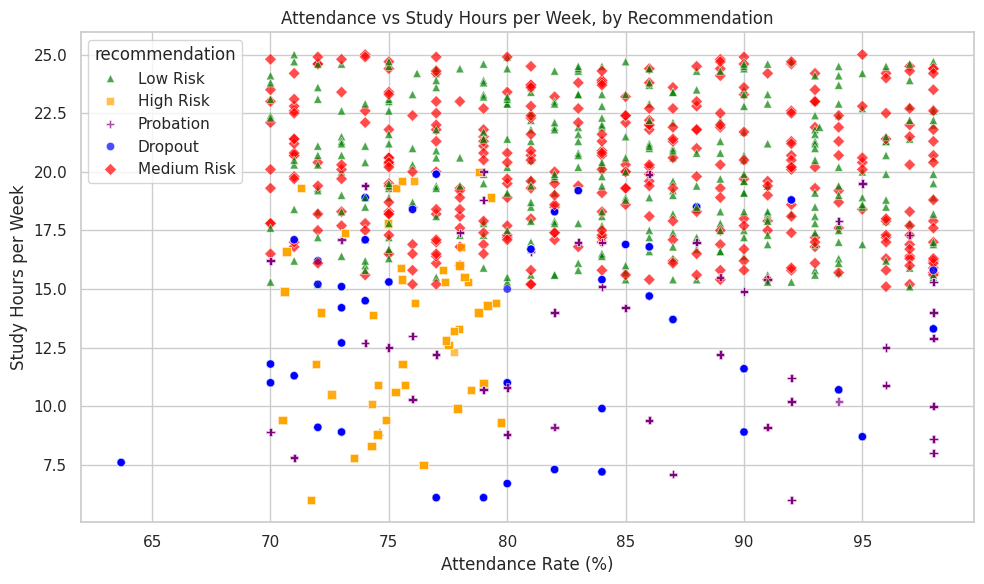

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("student_dataset_final_anonymized.csv")

sns.set(style="whitegrid")
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="attendanceRate",
    y="studyHours",
    hue="recommendation",
    style="recommendation",
    palette={
        "Dropout": "blue",
        "High Risk": "orange",
        "Low Risk": "green",
        "Medium Risk": "red",
        "Probation": "purple"
    },
    markers={
        "Dropout": "o",
        "High Risk": "s",
        "Low Risk": "^",
        "Medium Risk": "D",
        "Probation": "P"
    },
    alpha=0.7
)

plt.title("Attendance vs Study Hours per Week, by Recommendation")
plt.xlabel("Attendance Rate (%)")
plt.ylabel("Study Hours per Week")

plt.legend(title="recommendation")

plt.tight_layout()
plt.show()

Credit Hours vs Study Hours (by Recommendation)

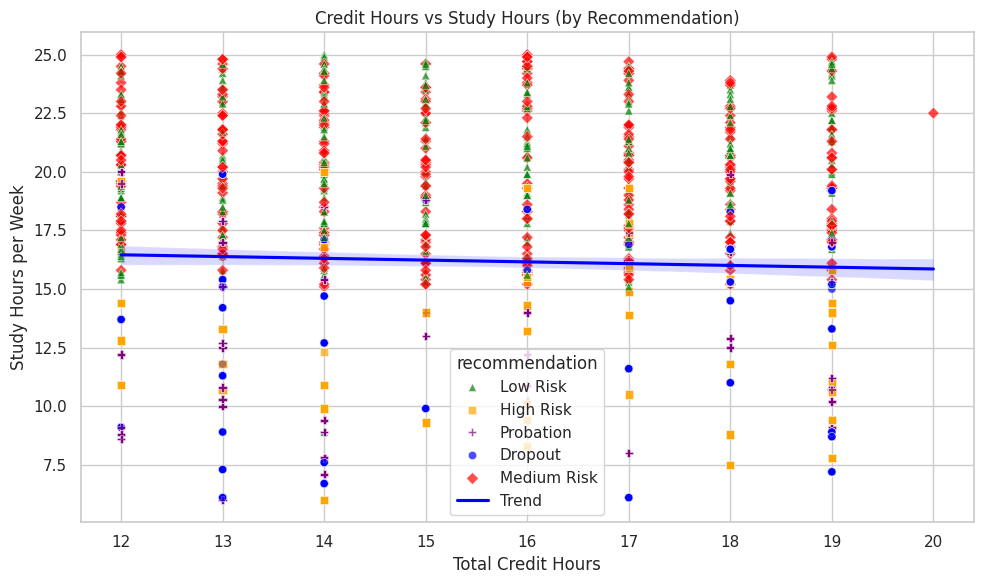

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("student_dataset_final_anonymized.csv")

sns.set(style="whitegrid")

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="totalcredithours",
    y="studyHours",
    hue="recommendation",
    style="recommendation",
    palette={
        "Dropout": "blue",
        "High Risk": "orange",
        "Low Risk": "green",
        "Medium Risk": "red",
        "Probation": "purple"
    },
    markers={
        "Dropout": "o",
        "High Risk": "s",
        "Low Risk": "^",
        "Medium Risk": "D",
        "Probation": "P"
    },
    alpha=0.7
)

sns.regplot(
    data=df,
    x="totalcredithours",
    y="studyHours",
    scatter=False,
    color="blue",
    label="Trend"
)

plt.title("Credit Hours vs Study Hours (by Recommendation)")
plt.xlabel("Total Credit Hours")
plt.ylabel("Study Hours per Week")

plt.legend(title="recommendation")
plt.tight_layout()
plt.show()

Distribution of Previous and Current CGPA

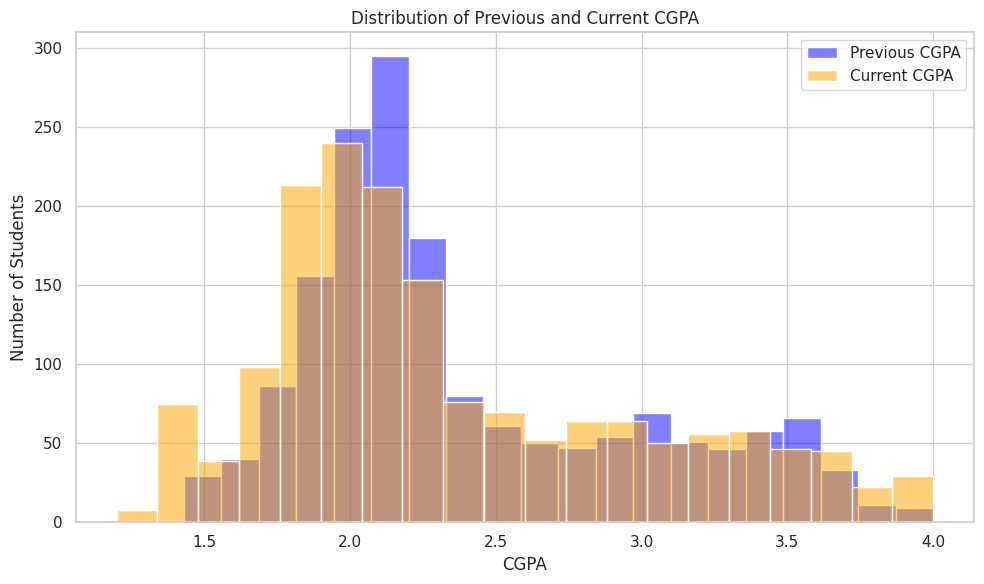

In [4]:
plt.figure(figsize=(10, 6))

sns.histplot(
    df["previousCGPA"],
    bins=20,
    kde=False,
    color="blue",
    label="Previous CGPA",
    alpha=0.5
)

sns.histplot(
    df["currentCGPA"],
    bins=20,
    kde=False,
    color="orange",
    label="Current CGPA",
    alpha=0.5
)

plt.title("Distribution of Previous and Current CGPA")
plt.xlabel("CGPA")
plt.ylabel("Number of Students")

plt.legend()
plt.tight_layout()
plt.show()

Percentage Enrollment Distribution per Semester

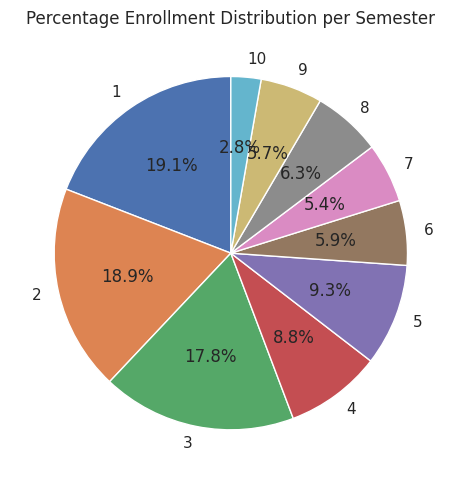

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("student_dataset_final_anonymized.csv")

semester_counts = df["semester"].value_counts().sort_index()

semester_percent = (semester_counts / semester_counts.sum()) * 100

plt.figure(figsize=(8, 5))
plt.pie(
    semester_percent,
    labels=semester_percent.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Percentage Enrollment Distribution per Semester")
plt.tight_layout()
plt.show()

Final Course Grade Distribution Across Students

/tmp/ipykernel_4773/229614036.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


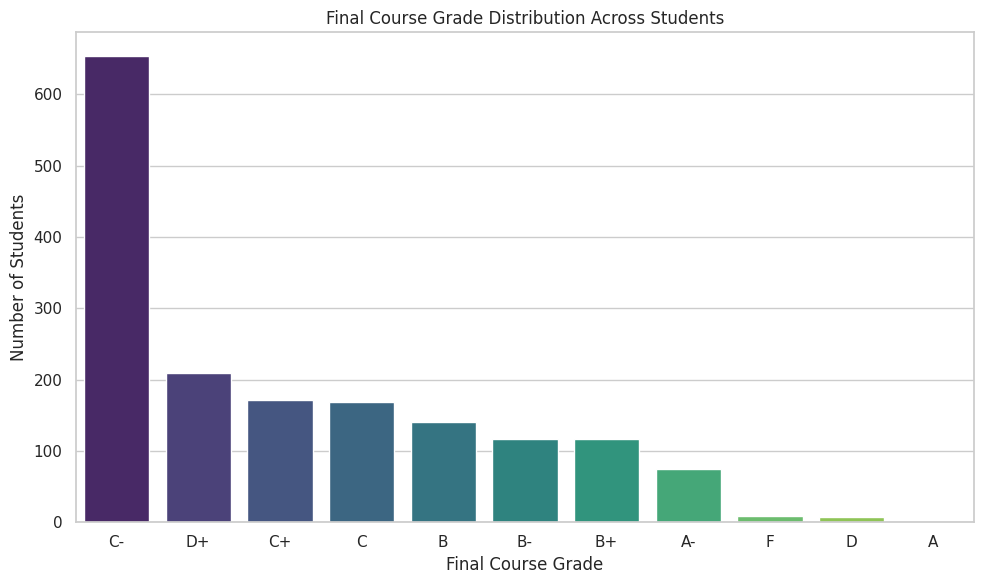

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x="next_semester_grade",
    order=df["next_semester_grade"].value_counts().index,
    palette="viridis"
)

plt.title("Final Course Grade Distribution Across Students")
plt.xlabel("Final Course Grade")
plt.ylabel("Number of Students")

plt.tight_layout()
plt.show()

Split target variables

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Load preprocessed dataset
df = pd.read_csv("student_dataset_final_preprocessed.csv")

print("Loaded shape:", df.shape)

# split target variables

X = df.drop(["next_semester_CGPA", "recommendation"], axis=1)

y_cgpa = df["next_semester_CGPA"]
y_reco = df["recommendation"]

print("X shape:", X.shape)
print("y_cgpa shape:", y_cgpa.shape)
print("y_reco shape:", y_reco.shape)

Loaded shape: (1670, 13)
X shape: (1670, 11)
y_cgpa shape: (1670,)
y_reco shape: (1670,)


Train/Test split

In [ ]:
# First split (training + temp)
X_train, X_temp, y_cgpa_train, y_cgpa_temp, y_reco_train, y_reco_temp = train_test_split(
    X, y_cgpa, y_reco,
    test_size=0.3,
    random_state=42
)

# Second split (validation + test)
X_val, X_test, y_cgpa_val, y_cgpa_test, y_reco_val, y_reco_test = train_test_split(
    X_temp, y_cgpa_temp, y_reco_temp,
    test_size=0.5,
    random_state=42
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (1169, 11)
Validation: (250, 11)
Test: (251, 11)


CNN input features shape

In [ ]:
import numpy as np

X_train = np.expand_dims(X_train.values, axis=2)
X_val   = np.expand_dims(X_val.values, axis=2)
X_test  = np.expand_dims(X_test.values, axis=2)

print("CNN input shape:", X_train.shape)

CNN input shape: (1169, 11, 1)


One-hot encoding for Target variable (classification)

In [ ]:
from tensorflow.keras.utils import to_categorical

num_classes = len(set(y_reco))

y_reco_train = to_categorical(y_reco_train, num_classes)
y_reco_val   = to_categorical(y_reco_val, num_classes)
y_reco_test  = to_categorical(y_reco_test, num_classes)

Drop target variables

In [ ]:
X = df.drop(["next_semester_CGPA", "recommendation"], axis=1)

Model Training (CNN+LSTM)

Loaded dataset shape: (1670, 13)

CNN/LSTM input shape: (1169, 11, 1)


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 11, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 11, 128)   │        512 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_2     │ (None, 5, 128)    │          0 │ conv1d_2[0][0]    │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 5, 128)    │          0 │ max_pooling1d_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ (None, 96)        │     86,400 │ dropout_6[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 96)        │          0 │ lstm_2[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 128)       │     12,416 │ dropout_7[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_8 (Dropout) │ (None, 128)       │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 64)        │      8,256 │ dropout_8[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cgpa_output (Dense) │ (None, 1)         │         65 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reco_output (Dense) │ (None, 5)         │        325 │ dense_5[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 107,974 (421.77 KB)

 Trainable params: 107,974 (421.77 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 6s 54ms/step - cgpa_output_loss: 3.2598 - cgpa_output_mae: 1.6131 - loss: 2.6444 - reco_output_accuracy: 0.2019 - reco_output_loss: 1.6393 - val_cgpa_output_loss: 0.6462 - val_cgpa_output_mae: 0.6340 - val_loss: 1.8831 - val_reco_output_accuracy: 0.2000 - val_reco_output_loss: 1.6886 - learning_rate: 7.0000e-04
Epoch 2/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - cgpa_output_loss: 0.5992 - cgpa_output_mae: 0.6210 - loss: 1.7901 - reco_output_accuracy: 0.2412 - reco_output_loss: 1.6059 - val_cgpa_output_loss: 0.3163 - val_cgpa_output_mae: 0.4440 - val_loss: 1.6391 - val_reco_output_accuracy: 0.2920 - val_reco_output_loss: 1.5439 - learning_rate: 7.0000e-04
Epoch 3/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - cgpa_output_loss: 0.4133 - cgpa_output_mae: 0.5088 - loss: 1.6416 - reco_output_accuracy: 0.3148 - reco_output_loss: 1.5134 - val_cgpa_output_loss: 0.2866 - val_cgpa_output_mae: 0.4222 - val_loss: 1.5033 - val_reco_output_accuracy: 0.3880 - v

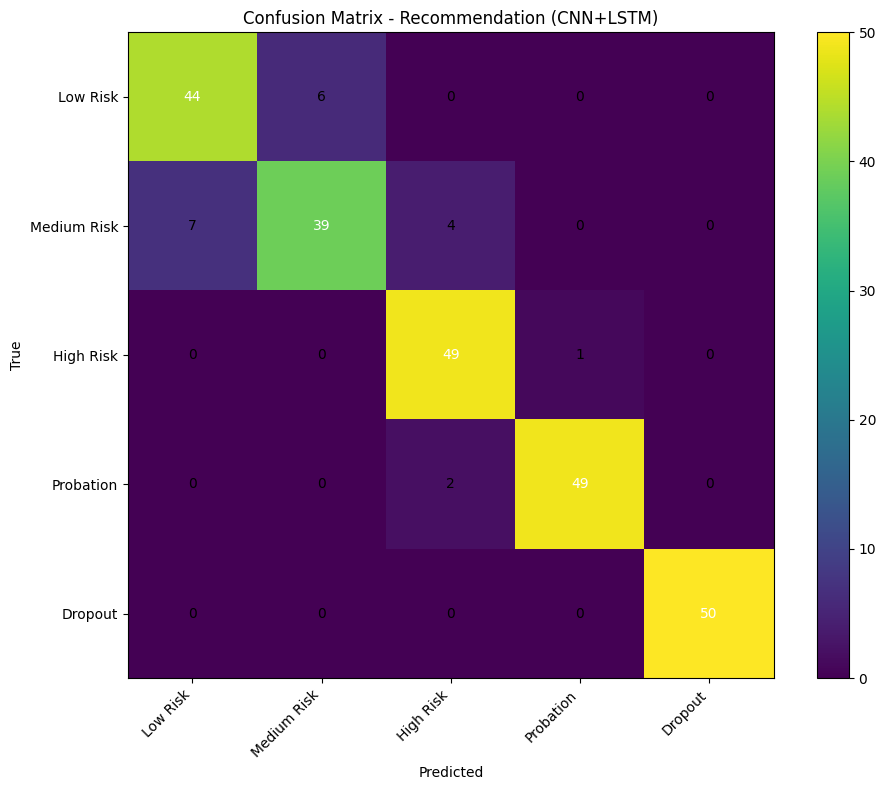


Regression Metrics (CGPA Prediction)
MAE : 0.2015
RMSE: 0.2605

Recommendation label mapping (index -> label):
{0: 'Low Risk', 1: 'Medium Risk', 2: 'High Risk', 3: 'Probation', 4: 'Dropout'}

Saved:
- classification_report_recommendation_final.csv
- cnn_lstm_history.csv


In [ ]:
# CNN+LSTM Model Training

import os
import random
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    balanced_accuracy_score, cohen_kappa_score, matthews_corrcoef,
    confusion_matrix, classification_report,
    mean_absolute_error, mean_squared_error
)

from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, LSTM, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

# Reproducibility

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)
tf.random.set_seed(SEED)

try:
    for g in tf.config.list_physical_devices("GPU"):
        tf.config.experimental.set_memory_growth(g, True)
except Exception:
    pass

# Config
DATA_PATH = "student_dataset_final_preprocessed.csv"
EPOCHS = 100
BATCH_SIZE = 64
TEST_SIZE = 0.15
VAL_SIZE = 0.15


# Label mapping
label_map = {
    0: "Low Risk",
    1: "Medium Risk",
    2: "High Risk",
    3: "Probation",
    4: "Dropout"
}
num_classes = 5
class_names = [label_map[i] for i in range(num_classes)]

# Load dataset
df = pd.read_csv(DATA_PATH)
print("Loaded dataset shape:", df.shape)

# Selected features
feature_cols = [
    "course1_marks", "course2_marks", "course3_marks",
    "course4_marks", "course5_marks",
    "currentCGPA", "previousCGPA", "semester",
    "totalcredithours", "attendanceRate", "studyHours"
]

required_cols = feature_cols + ["next_semester_CGPA", "recommendation"]
missing_cols = [c for c in required_cols if c not in df.columns]
if missing_cols:
    raise ValueError(f"Missing required columns in dataset: {missing_cols}")

X = df[feature_cols].copy()
y_cgpa = df["next_semester_CGPA"].astype(float).copy()
y_reco = df["recommendation"].astype(int).copy()

temp_size = TEST_SIZE + VAL_SIZE

X_train, X_temp, y_cgpa_train, y_cgpa_temp, y_reco_train, y_reco_temp = train_test_split(
   X, y_cgpa, y_reco,
    test_size=temp_size,
    random_state=SEED,
    stratify=y_reco
)

relative_test_size = TEST_SIZE / (TEST_SIZE + VAL_SIZE)

X_val, X_test, y_cgpa_val, y_cgpa_test, y_reco_val, y_reco_test = train_test_split(
    X_temp, y_cgpa_temp, y_reco_temp,
    test_size=relative_test_size,
    random_state=SEED,
    stratify=y_reco_temp
)

y_reco_cat_train = to_categorical(y_reco_train, num_classes=num_classes)
y_reco_cat_val   = to_categorical(y_reco_val,   num_classes=num_classes)
y_reco_cat_test  = to_categorical(y_reco_test,  num_classes=num_classes)

X_train_scaled = X_train.values.astype(np.float32)
X_val_scaled   = X_val.values.astype(np.float32)
X_test_scaled  = X_test.values.astype(np.float32)

def to_3d(X2D):
    return X2D.reshape((X2D.shape[0], X2D.shape[1], 1)).astype(np.float32)

X_train_3d = to_3d(X_train_scaled)
X_val_3d   = to_3d(X_val_scaled)
X_test_3d  = to_3d(X_test_scaled)

print("\nCNN/LSTM input shape:", X_train_3d.shape)

# model build
def build_model(n_features, n_classes):
    inp = Input(shape=(n_features, 1))

    x = Conv1D(128, 3, activation="relu", padding="same")(inp)
    x = MaxPooling1D(2)(x)
    x = Dropout(0.20)(x)

    x = LSTM(96, return_sequences=False)(x)
    x = Dropout(0.20)(x)

    shared = Dense(128, activation="relu")(x)
    shared = Dropout(0.20)(shared)
    shared = Dense(64, activation="relu")(shared)

    out_cgpa = Dense(1, activation="linear", name="cgpa_output")(shared)
    out_reco = Dense(n_classes, activation="softmax", name="reco_output")(shared)

    model = Model(inputs=inp, outputs=[out_cgpa, out_reco])

    model.compile(
        optimizer=Adam(learning_rate=7e-4),
        loss={
            "cgpa_output": "mse",
            "reco_output": "categorical_crossentropy"
        },
        loss_weights={
            "cgpa_output": 0.3,
            "reco_output": 1.0
        },
        metrics={
            "cgpa_output": ["mae"],
            "reco_output": ["accuracy"]
        }
    )
    return model

model = build_model(X_train_3d.shape[1], num_classes)
model.summary()

callbacks = [
    EarlyStopping(
        monitor="val_reco_output_accuracy",
        patience=15,
        mode="max",
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor="val_reco_output_accuracy",
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        mode="max"
    )
]

# Train
history = model.fit(
    X_train_3d,
    {
        "cgpa_output": y_cgpa_train.values,
        "reco_output": y_reco_cat_train
    },
    validation_data=(
        X_val_3d,
        {
            "cgpa_output": y_cgpa_val.values,
            "reco_output": y_reco_cat_val
        }
    ),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)

# Evaluate
eval_results = model.evaluate(
    X_test_3d,
    {
        "cgpa_output": y_cgpa_test.values,
        "reco_output": y_reco_cat_test
    },
    verbose=0
)

print("\nRaw evaluate output:", eval_results)

pred_cgpa, pred_reco_probs = model.predict(X_test_3d, verbose=0)
pred_reco_idx = np.argmax(pred_reco_probs, axis=1)

acc_reco = accuracy_score(y_reco_test, pred_reco_idx)
mae_cgpa = mean_absolute_error(y_cgpa_test, pred_cgpa.flatten())

print(f"\nTest — CGPA_MAE: {mae_cgpa:.4f} | Reco_Acc: {acc_reco:.4f}")
print("Sample CGPA preds:", pred_cgpa[:5].flatten())
print("Sample Reco preds:", [label_map[i] for i in pred_reco_idx[:5]])

def predict_next_semester(df_new: pd.DataFrame) -> pd.DataFrame:
    missing = [c for c in feature_cols if c not in df_new.columns]
    if missing:
        raise ValueError(f"Missing required feature columns: {missing}")

    x = df_new[feature_cols].astype(float).values.astype(np.float32)
    x_3d = to_3d(x)

    cgpa_pred, reco_probs = model.predict(x_3d, verbose=0)
    reco_idx = np.argmax(reco_probs, axis=1)

    return pd.DataFrame({
        "pred_next_semester_CGPA": cgpa_pred.flatten(),
        "pred_recommendation": [label_map[i] for i in reco_idx]
    }, index=df_new.index)

demo_new = X_test.iloc[:3].copy()
print("\nPredictions on 3 new rows:")
print(predict_next_semester(demo_new))

y_pred_cgpa = pred_cgpa.flatten()
y_pred_reco = pred_reco_idx
y_true_reco = y_reco_test.values

acc  = accuracy_score(y_true_reco, y_pred_reco)
prec = precision_score(y_true_reco, y_pred_reco, average="weighted", zero_division=0)
rec  = recall_score(y_true_reco, y_pred_reco, average="weighted", zero_division=0)
f1   = f1_score(y_true_reco, y_pred_reco, average="weighted", zero_division=0)

print("\nClassification Metrics (Recommendation)")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")

all_labels = np.arange(num_classes)

print("\nFull classification report:\n")
report_text = classification_report(
    y_true_reco,
    y_pred_reco,
    labels=all_labels,
    target_names=class_names,
    zero_division=0,
    digits=4
)
print(report_text)

report_dict = classification_report(
    y_true_reco,
    y_pred_reco,
    labels=all_labels,
    target_names=class_names,
    zero_division=0,
    output_dict=True
)
pd.DataFrame(report_dict).T.to_csv("classification_report_recommendation_final.csv", index=True)

micro_f1 = f1_score(y_true_reco, y_pred_reco, average="micro", zero_division=0)
macro_f1 = f1_score(y_true_reco, y_pred_reco, average="macro", zero_division=0)
bal_acc  = balanced_accuracy_score(y_true_reco, y_pred_reco)
kappa    = cohen_kappa_score(y_true_reco, y_pred_reco, labels=all_labels)
mcc      = matthews_corrcoef(y_true_reco, y_pred_reco)

print("\nAdditional summary metrics")
print(f"Micro-F1           : {micro_f1:.4f}")
print(f"Macro-F1           : {macro_f1:.4f}")
print(f"Balanced Accuracy  : {bal_acc:.4f}")
print(f"Cohen's Kappa      : {kappa:.4f}")
print(f"Matthews Corrcoef  : {mcc:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_true_reco, y_pred_reco, labels=all_labels)

plt.figure(figsize=(10, 8))
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix - Recommendation (CNN+LSTM)")
plt.colorbar()

ticks = np.arange(len(class_names))
plt.xticks(ticks, class_names, rotation=45, ha="right")
plt.yticks(ticks, class_names)

thresh = cm.max() / 2.0 if cm.size else 0.0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j, i, format(cm[i, j], "d"),
            ha="center", va="center",
            color="white" if cm[i, j] > thresh else "black"
        )

plt.ylabel("True")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

# Regression metrics
mask = np.isfinite(y_cgpa_test.values) & np.isfinite(y_pred_cgpa)
y_true_c = y_cgpa_test.values[mask]
y_pred_c = y_pred_cgpa[mask]

mae = mean_absolute_error(y_true_c, y_pred_c)
try:
    rmse = mean_squared_error(y_true_c, y_pred_c, squared=False)
except TypeError:
    rmse = np.sqrt(mean_squared_error(y_true_c, y_pred_c))

print("\nRegression Metrics (CGPA Prediction)")
print(f"MAE : {mae:.4f}")
print(f"RMSE: {rmse:.4f}")

print("\nRecommendation label mapping (index -> label):")
print(label_map)

# Save outputs
history_df = pd.DataFrame(history.history)
history_df.to_csv("cnn_lstm_history.csv", index=False)

print("\nSaved:")
print("- classification_report_recommendation_final.csv")
print("- cnn_lstm_history.csv")

Recommendation class distribution True vs. Predicted values plot

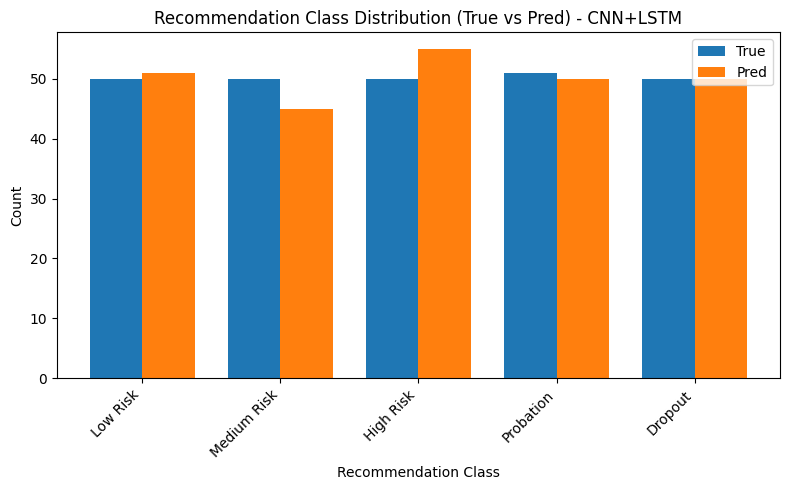

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Ensure arrays
y_true_reco_arr = np.asarray(y_true_reco, dtype=int)
y_pred_reco_arr = np.asarray(y_pred_reco, dtype=int)

true_counts = np.bincount(y_true_reco_arr, minlength=num_classes)
pred_counts = np.bincount(y_pred_reco_arr, minlength=num_classes)

x = np.arange(num_classes)
w = 0.38

plt.figure(figsize=(8, 5))
plt.bar(x - w/2, true_counts, width=w, label="True")
plt.bar(x + w/2, pred_counts, width=w, label="Pred")

plt.xticks(x, class_names, rotation=45, ha="right")
plt.ylabel("Count")
plt.xlabel("Recommendation Class")
plt.title("Recommendation Class Distribution (True vs Pred) - CNN+LSTM")
plt.legend()
plt.tight_layout()
plt.show()

Both Training and Validation Accuracy and Model Loss plot of both recommendation and cgpa

Available history keys:
dict_keys(['cgpa_output_loss', 'cgpa_output_mae', 'loss', 'reco_output_accuracy', 'reco_output_loss', 'val_cgpa_output_loss', 'val_cgpa_output_mae', 'val_loss', 'val_reco_output_accuracy', 'val_reco_output_loss', 'learning_rate'])


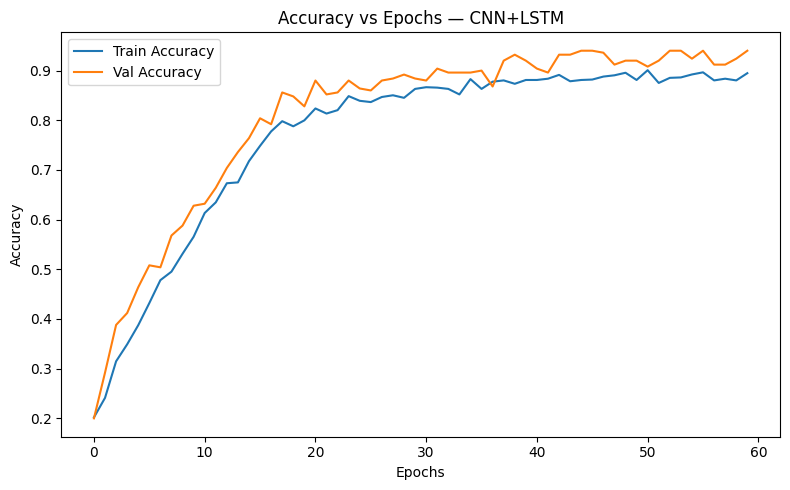

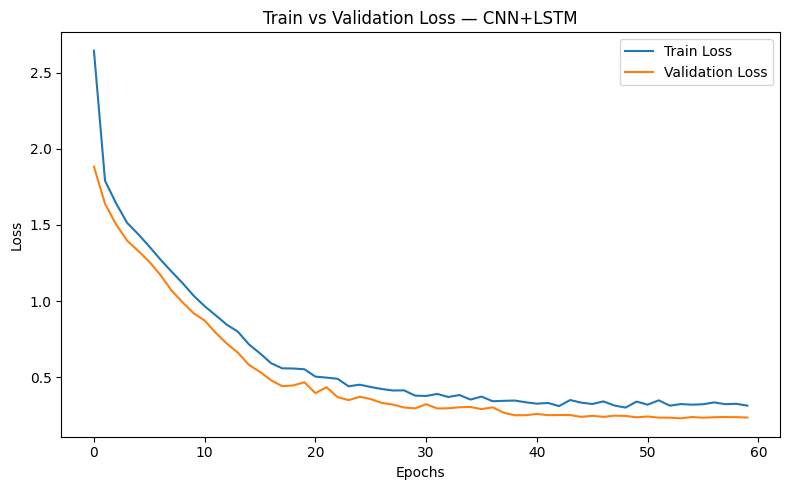

In [ ]:
import matplotlib.pyplot as plt

# Plot Accuracy and Loss for CNN+LSTM

print("Available history keys:")
print(history.history.keys())

# Accuracy Plot
plt.figure(figsize=(8, 5))
plt.plot(history.history["reco_output_accuracy"], label="Train Accuracy")
plt.plot(history.history["val_reco_output_accuracy"], label="Val Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Epochs — CNN+LSTM")
plt.legend()
plt.tight_layout()
plt.show()

# Loss Plot
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Train vs Validation Loss — CNN+LSTM")
plt.legend()
plt.tight_layout()
plt.show()

Specific Recommendation Accuracy and Model Loss plot

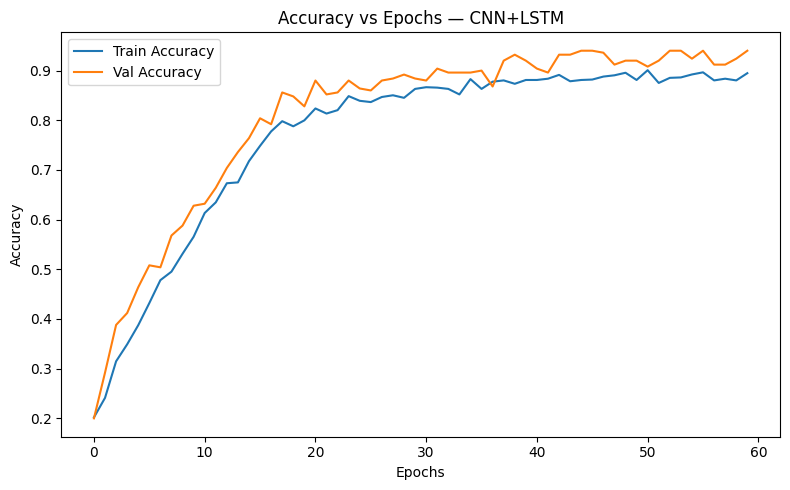

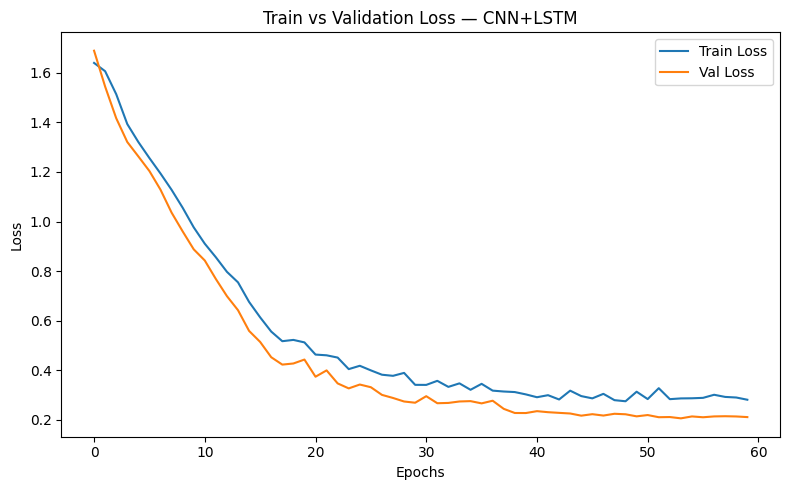

In [ ]:
import matplotlib.pyplot as plt

# Recommendation Accuracy Plot
plt.figure(figsize=(8, 5))
plt.plot(history.history["reco_output_accuracy"], label="Train Accuracy")
plt.plot(history.history["val_reco_output_accuracy"], label="Val Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Epochs — CNN+LSTM")
plt.legend()
plt.tight_layout()
plt.show()

# Recommendation Loss Plot
plt.figure(figsize=(8, 5))
plt.plot(history.history["reco_output_loss"], label="Train Loss")
plt.plot(history.history["val_reco_output_loss"], label="Val Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Train vs Validation Loss — CNN+LSTM")
plt.legend()
plt.tight_layout()
plt.show()

Specific CGPA Model Loss vs. epochs plot

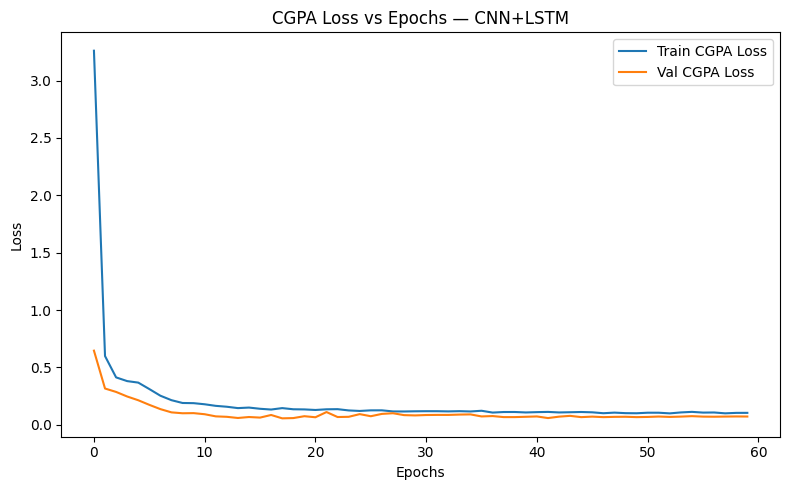

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(history.history["cgpa_output_loss"], label="Train CGPA Loss")
plt.plot(history.history["val_cgpa_output_loss"], label="Val CGPA Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("CGPA Loss vs Epochs — CNN+LSTM")
plt.legend()
plt.tight_layout()
plt.show()

Precision-Recall-CNN+LSTM plot

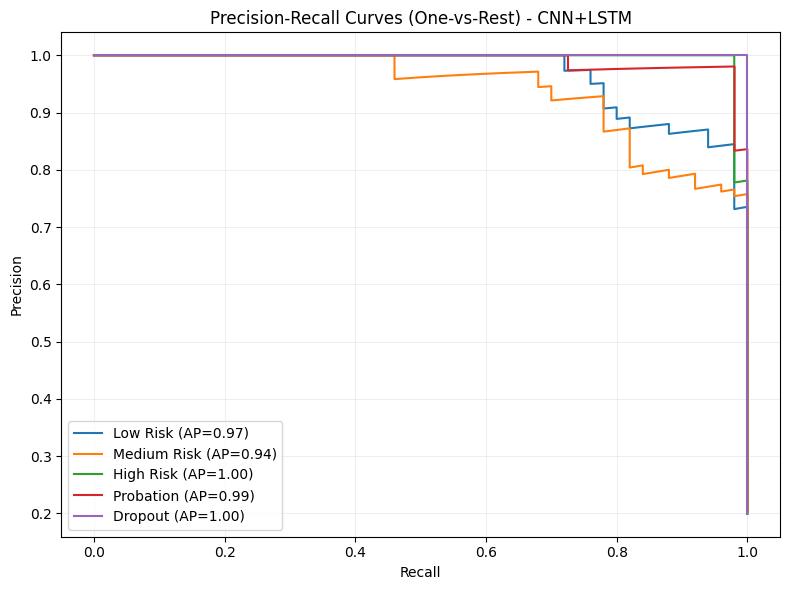

Per-class Average Precision:
Low Risk: 0.9672
Medium Risk: 0.9415
High Risk: 0.9956
Probation: 0.9911
Dropout: 1.0000

Macro Average Precision: 0.9791


In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import precision_recall_curve, average_precision_score
import numpy as np
import matplotlib.pyplot as plt

y_true_reco_arr = np.asarray(y_true_reco, dtype=int)
pred_reco_probs_arr = np.asarray(pred_reco_probs, dtype=float)

classes = np.arange(num_classes)
Y_true_bin = label_binarize(y_true_reco_arr, classes=classes)

ap_scores = []
plt.figure(figsize=(8, 6))

for c in range(num_classes):
    y_true_c = Y_true_bin[:, c]
    y_score_c = pred_reco_probs_arr[:, c]

    precision_c, recall_c, _ = precision_recall_curve(y_true_c, y_score_c)
    ap_c = average_precision_score(y_true_c, y_score_c)
    ap_scores.append(ap_c)

    plt.plot(recall_c, precision_c, label=f"{class_names[c]} (AP={ap_c:.2f})")

macro_ap = np.mean(ap_scores)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Precision-Recall Curves (One-vs-Rest) - CNN+LSTM")
plt.legend()
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

print("Per-class Average Precision:")
for c, ap_c in enumerate(ap_scores):
    print(f"{class_names[c]}: {ap_c:.4f}")

print(f"\nMacro Average Precision: {macro_ap:.4f}")

ROC curve - CNN+LSTM plot

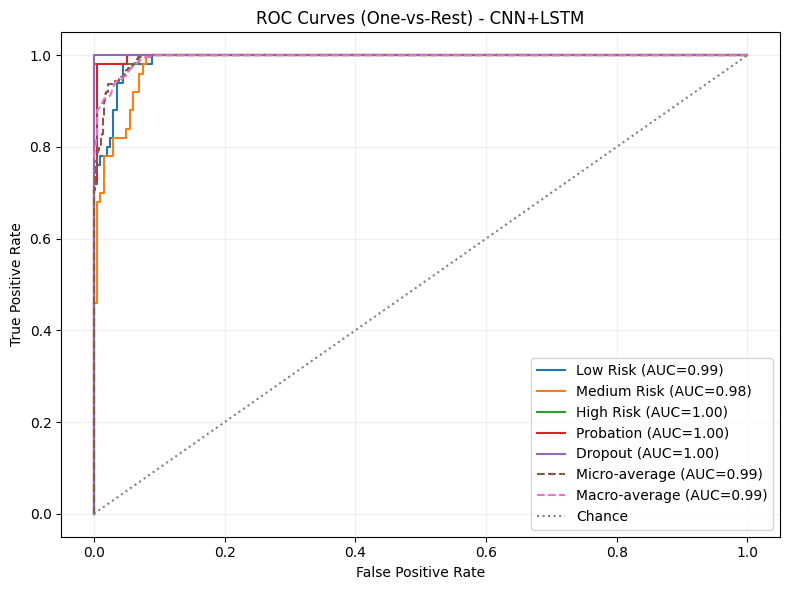

Per-class ROC-AUC:
Low Risk: 0.9912
Medium Risk: 0.9849
High Risk: 0.9986
Probation: 0.9977
Dropout: 1.0000

Micro-average ROC-AUC: 0.9942
Macro-average ROC-AUC: 0.9949

ROC-AUC Results Table:
           Class   ROC_AUC
0       Low Risk  0.991244
1    Medium Risk  0.984876
2      High Risk  0.998607
3      Probation  0.997745
4        Dropout  1.000000
5  Micro-average  0.994242
6  Macro-average  0.994938


In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

y_true_reco_arr = np.asarray(y_true_reco, dtype=int)
pred_reco_probs_arr = np.asarray(pred_reco_probs, dtype=float)

classes = np.arange(num_classes)
Y_true_bin = label_binarize(y_true_reco_arr, classes=classes)

fpr = {}
tpr = {}
roc_auc = {}

# Per-class ROC
for c in range(num_classes):
    fpr[c], tpr[c], _ = roc_curve(Y_true_bin[:, c], pred_reco_probs_arr[:, c])
    roc_auc[c] = auc(fpr[c], tpr[c])

# Micro-average ROC
fpr["micro"], tpr["micro"], _ = roc_curve(Y_true_bin.ravel(), pred_reco_probs_arr.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Macro-average ROC
all_fpr = np.unique(np.concatenate([fpr[c] for c in range(num_classes)]))
mean_tpr = np.zeros_like(all_fpr)

for c in range(num_classes):
    mean_tpr += np.interp(all_fpr, fpr[c], tpr[c])

mean_tpr /= num_classes
fpr["macro"] = all_fpr
tpr["macro"] = mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

# Plot
plt.figure(figsize=(8, 6))

for c in range(num_classes):
    plt.plot(
        fpr[c], tpr[c],
        label=f"{class_names[c]} (AUC={roc_auc[c]:.2f})"
    )

plt.plot(
    fpr["micro"], tpr["micro"],
    linestyle="--",
    label=f"Micro-average (AUC={roc_auc['micro']:.2f})"
)

plt.plot(
    fpr["macro"], tpr["macro"],
    linestyle="--",
    label=f"Macro-average (AUC={roc_auc['macro']:.2f})"
)

plt.plot([0, 1], [0, 1], linestyle=":", label="Chance")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves (One-vs-Rest) - CNN+LSTM")
plt.legend()
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

print("Per-class ROC-AUC:")
for c in range(num_classes):
    print(f"{class_names[c]}: {roc_auc[c]:.4f}")

print(f"\nMicro-average ROC-AUC: {roc_auc['micro']:.4f}")
print(f"Macro-average ROC-AUC: {roc_auc['macro']:.4f}")

roc_results_df = pd.DataFrame({
    "Class": class_names,
    "ROC_AUC": [roc_auc[c] for c in range(num_classes)]
})

roc_results_df.loc[len(roc_results_df)] = ["Micro-average", roc_auc["micro"]]
roc_results_df.loc[len(roc_results_df)] = ["Macro-average", roc_auc["macro"]]

print("\nROC-AUC Results Table:")
print(roc_results_df)

roc_results_df.to_csv("roc_auc_results.csv", index=False)

Classification Confidence Distribution plot — CNN+LSTM

Mean Confidence: 0.8870
Std Confidence : 0.1316


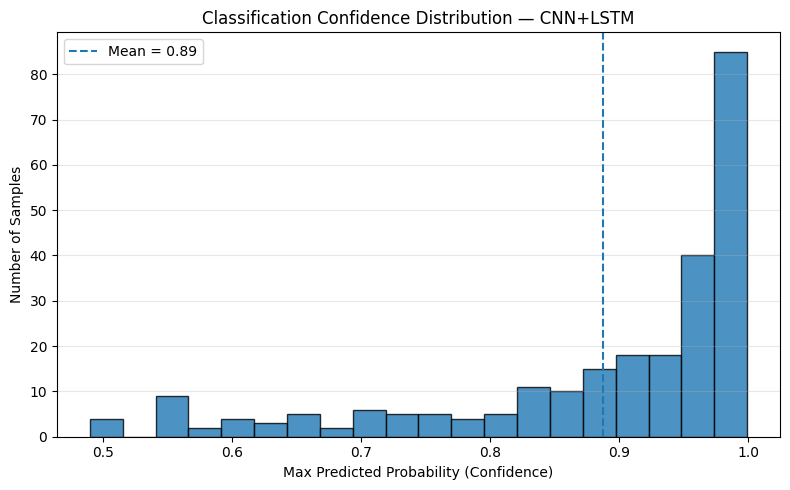

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

pred_reco_probs_arr = np.asarray(pred_reco_probs, dtype=float)

cls_confidence = np.max(pred_reco_probs_arr, axis=1)

mean_conf = np.mean(cls_confidence)
std_conf  = np.std(cls_confidence)

print(f"Mean Confidence: {mean_conf:.4f}")
print(f"Std Confidence : {std_conf:.4f}")

# Plot
plt.figure(figsize=(8, 5))
plt.hist(
    cls_confidence,
    bins=20,
    edgecolor="black",
    alpha=0.8
)

plt.axvline(mean_conf, linestyle="--", label=f"Mean = {mean_conf:.2f}")

plt.xlabel("Max Predicted Probability (Confidence)")
plt.ylabel("Number of Samples")
plt.title("Classification Confidence Distribution — CNN+LSTM")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

Regression Confidence Distribution plot - CNN+LSTM

Mean Regression Confidence: 0.9465
Std Regression Confidence : 0.0438


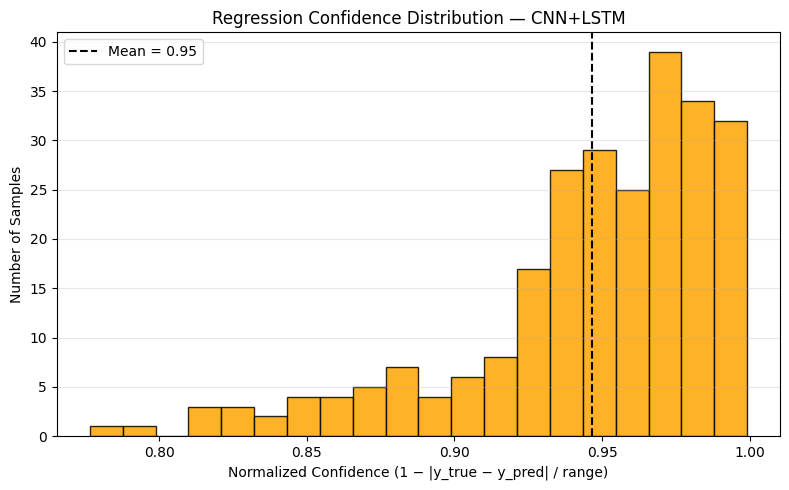

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Ensure arrays
y_true_c = np.asarray(y_cgpa_test, dtype=float)
y_pred_c = np.asarray(y_pred_cgpa, dtype=float).flatten()

cgpa_range = np.max(y_true_c) - np.min(y_true_c)
cgpa_range = cgpa_range if cgpa_range != 0 else 1.0

reg_confidence = 1.0 - (np.abs(y_true_c - y_pred_c) / cgpa_range)
reg_confidence = np.clip(reg_confidence, 0, 1)

mean_conf = np.mean(reg_confidence)
std_conf  = np.std(reg_confidence)

print(f"Mean Regression Confidence: {mean_conf:.4f}")
print(f"Std Regression Confidence : {std_conf:.4f}")

# Plot
plt.figure(figsize=(8, 5))
plt.hist(
    reg_confidence,
    bins=20,
    color="orange",
    edgecolor="black",
    alpha=0.85
)

plt.axvline(mean_conf, linestyle="--", color="black", label=f"Mean = {mean_conf:.2f}")

plt.xlabel("Normalized Confidence (1 − |y_true − y_pred| / range)")
plt.ylabel("Number of Samples")
plt.title("Regression Confidence Distribution — CNN+LSTM")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

Predicted vs True CGPA (Regression confidence) plot — CNN+LSTM

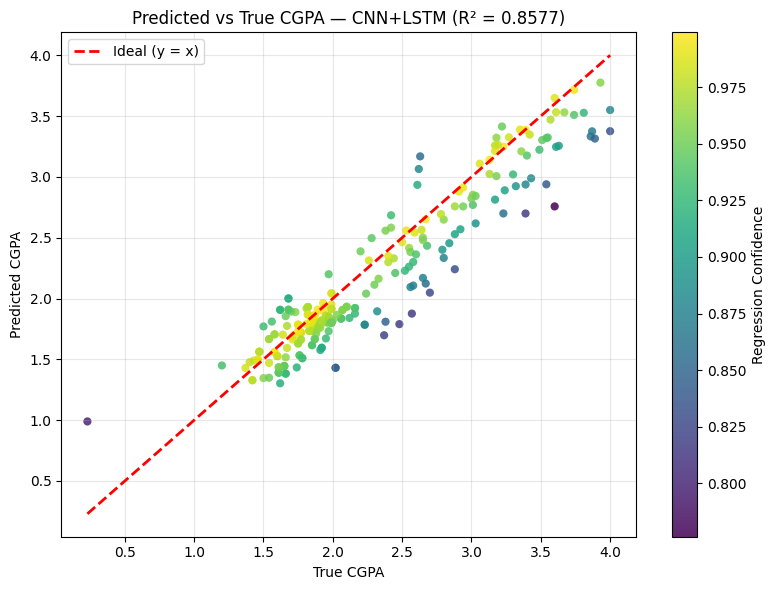

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

y_true_c = np.asarray(y_cgpa_test, dtype=float)
y_pred_c = np.asarray(y_pred_cgpa, dtype=float).flatten()

r2 = r2_score(y_true_c, y_pred_c)

cgpa_range = np.max(y_true_c) - np.min(y_true_c)
cgpa_range = cgpa_range if cgpa_range != 0 else 1.0

reg_confidence = 1.0 - (np.abs(y_true_c - y_pred_c) / cgpa_range)
reg_confidence = np.clip(reg_confidence, 0, 1)

# Plot
plt.figure(figsize=(8, 6))

sc = plt.scatter(
    y_true_c,
    y_pred_c,
    c=reg_confidence,
    cmap="viridis",
    s=35,
    alpha=0.85,
    edgecolors="none"
)

min_cgpa = min(y_true_c.min(), y_pred_c.min())
max_cgpa = max(y_true_c.max(), y_pred_c.max())

plt.plot(
    [min_cgpa, max_cgpa],
    [min_cgpa, max_cgpa],
    linestyle="--",
    color="red",
    linewidth=2,
    label="Ideal (y = x)"
)

plt.xlabel("True CGPA")
plt.ylabel("Predicted CGPA")
plt.title(f"Predicted vs True CGPA — CNN+LSTM (R² = {r2:.4f})")
plt.legend()
plt.grid(True, alpha=0.3)

# Colorbar
cbar = plt.colorbar(sc)
cbar.set_label("Regression Confidence")

plt.tight_layout()
plt.show()

Predicted CGPA vs Recommendation Confidence plot — CNN+LSTM

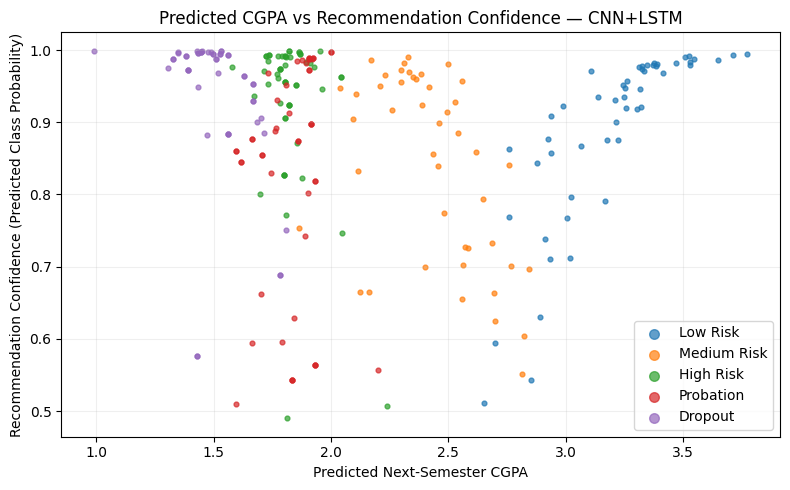

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

y_pred_cgpa_arr = np.asarray(y_pred_cgpa, dtype=float).flatten()
y_pred_reco_arr = np.asarray(y_pred_reco, dtype=int)
pred_reco_probs_arr = np.asarray(pred_reco_probs, dtype=float)

plt.figure(figsize=(8, 5))

for c in range(num_classes):
    mask = (y_pred_reco_arr == c)

    if not np.any(mask):
        continue

    plt.scatter(
        y_pred_cgpa_arr[mask],
        pred_reco_probs_arr[mask, c],
        s=12,
        alpha=0.7,
        label=class_names[c]
    )

plt.xlabel("Predicted Next-Semester CGPA")
plt.ylabel("Recommendation Confidence (Predicted Class Probability)")
plt.title("Predicted CGPA vs Recommendation Confidence — CNN+LSTM")
plt.legend(markerscale=2, frameon=True)
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

Model Training ANN+CNN, CNN+LSTM and other comparative models

Loaded dataset shape: (1670, 13)
X shape: (1670, 11)
y_cgpa shape: (1670,)
y_reco shape: (1670,)

Recommendation class distribution:
recommendation
0    334
1    334
2    334
3    334
4    334
Name: count, dtype: int64

3D input shape: (1169, 11, 1)

ASSIST-inspired branch shapes:
Academic   : (1169, 5, 1)
Progress   : (1169, 4, 1)
Behaviour  : (1169, 2, 1)
Assessment : (1169, 2)

################################################################################
Training model: CNN+LSTM
################################################################################


Model: "CNN_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 11, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 11, 128)   │        512 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 5, 128)    │          0 │ conv1d[0][0]      │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 5, 128)    │          0 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 96)        │     86,400 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 96)        │          0 │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │     12,416 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 128)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │      8,256 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cgpa_output (Dense) │ (None, 1)         │         65 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reco_output (Dense) │ (None, 5)         │        325 │ dense_1[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 107,974 (421.77 KB)

 Trainable params: 107,974 (421.77 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ academic_input      │ (None, 5, 1)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ progress_input      │ (None, 4, 1)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ behaviour_input     │ (None, 2, 1)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ academic_bilstm     │ (None, 5, 64)     │      8,704 │ academic_input[0… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ progress_bilstm     │ (None, 4, 64)     │      8,704 │ progress_input[0… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ behaviour_bilstm    │ (None, 2, 32)     │      2,304 │ behaviour_input[… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ academic_attention  │ (None, 64)        │         69 │ academic_bilstm[… │
│ (TemporalAttention) │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ progress_attention  │ (None, 64)        │         68 │ progress_bilstm[… │
│ (TemporalAttention) │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ behaviour_attention │ (None, 32)        │         34 │ behaviour_bilstm… │
│ (TemporalAttention) │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ assessment_input    │ (None, 2)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ academic_dense      │ (None, 32)        │      2,080 │ academic_attenti… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ progress_dense      │ (None, 32)        │      2,080 │ progress_attenti… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ behaviour_dense     │ (None, 32)        │      1,056 │ behaviour_attent… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ assessment_dense    │ (None, 16)        │         48 │ assessment_input… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ assist_concat_layer │ (None, 112)       │          0 │ academic_dense[0… │
│ (Concatenate)       │                   │            │ progress_dense[0… │
│                     │                   │            │ behaviour_dense[… │
│                     │                   │            │ assessment_dense… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ assist_fusion_dens… │ (None, 128)       │     14,464 │ assist_concat_la… │
│ (Dense)             │                   │            │                 

 Total params: 48,257 (188.50 KB)

 Trainable params: 48,257 (188.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 19s 189ms/step - cgpa_output_loss: 4.2023 - cgpa_output_mae: 1.9232 - loss: 2.8692 - reco_output_accuracy: 0.3165 - reco_output_loss: 1.5826 - val_cgpa_output_loss: 2.4342 - val_cgpa_output_mae: 1.3835 - val_loss: 2.2831 - val_reco_output_accuracy: 0.3440 - val_reco_output_loss: 1.5522 - learning_rate: 7.0000e-04
Epoch 2/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - cgpa_output_loss: 1.1909 - cgpa_output_mae: 0.8838 - loss: 1.8631 - reco_output_accuracy: 0.3798 - reco_output_loss: 1.4949 - val_cgpa_output_loss: 0.4633 - val_cgpa_output_mae: 0.4903 - val_loss: 1.5266 - val_reco_output_accuracy: 0.4080 - val_reco_output_loss: 1.3867 - learning_rate: 7.0000e-04
Epoch 3/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - cgpa_output_loss: 0.4326 - cgpa_output_mae: 0.5003 - loss: 1.4277 - reco_output_accuracy: 0.4277 - reco_output_loss: 1.2913 - val_cgpa_output_loss: 0.2233 - val_cgpa_output_mae: 0.3715 - val_loss: 1.2375 - val_reco_output_accuracy: 0.4840 -

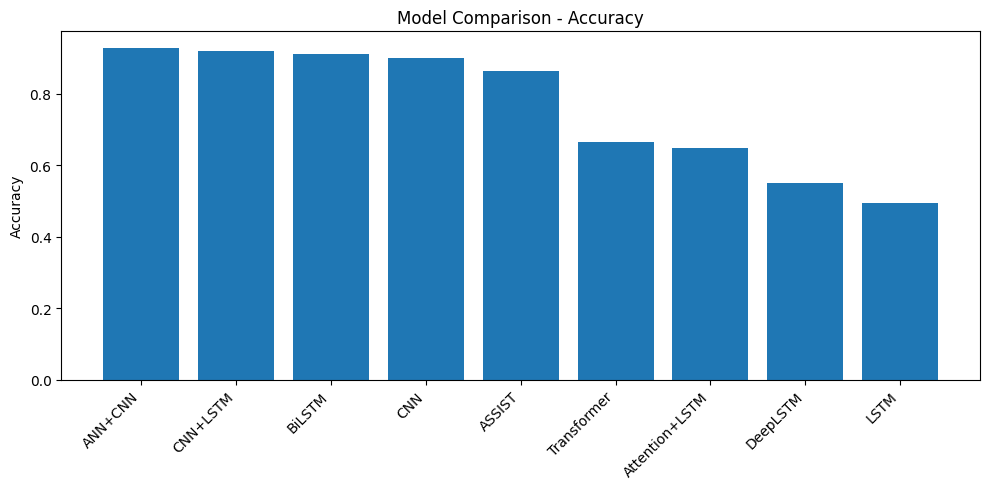

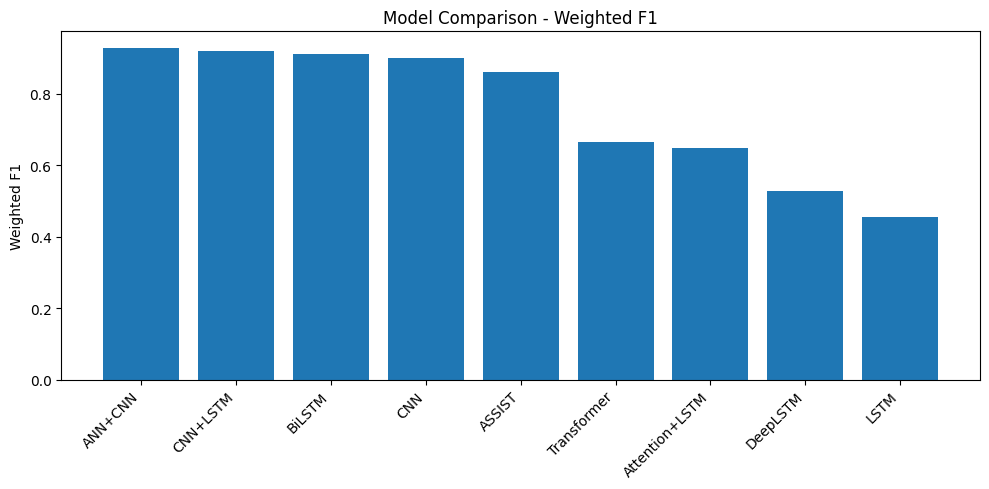

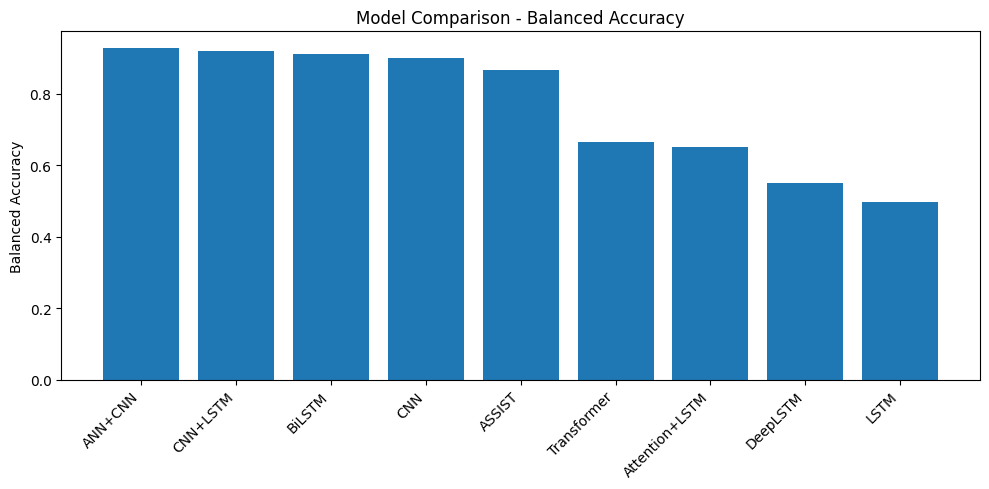

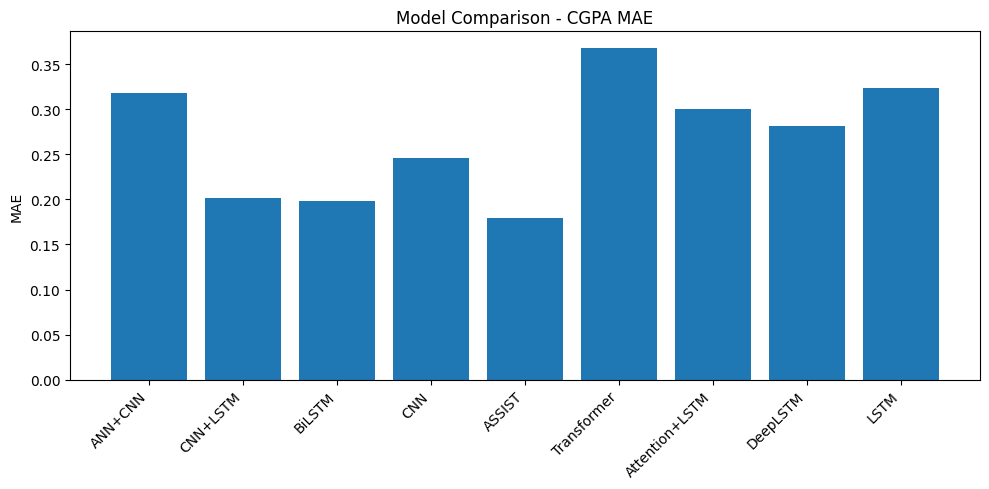

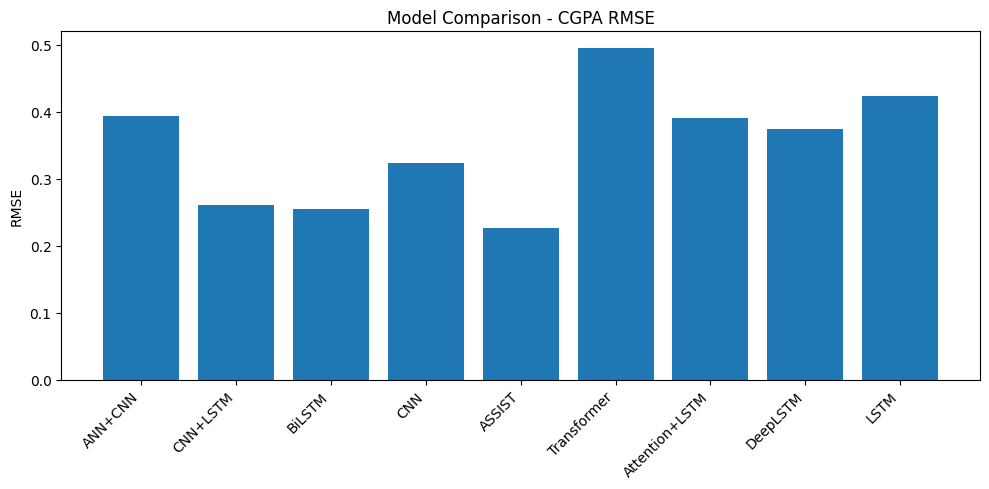

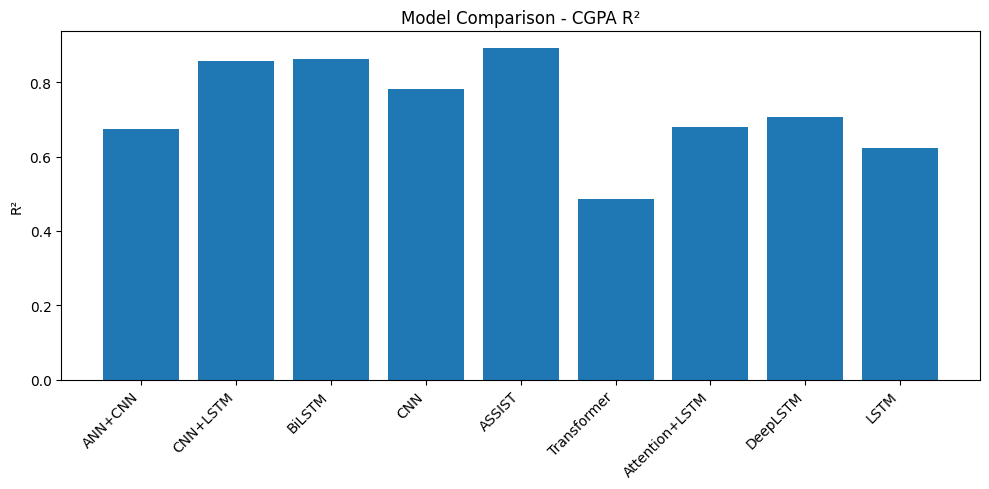

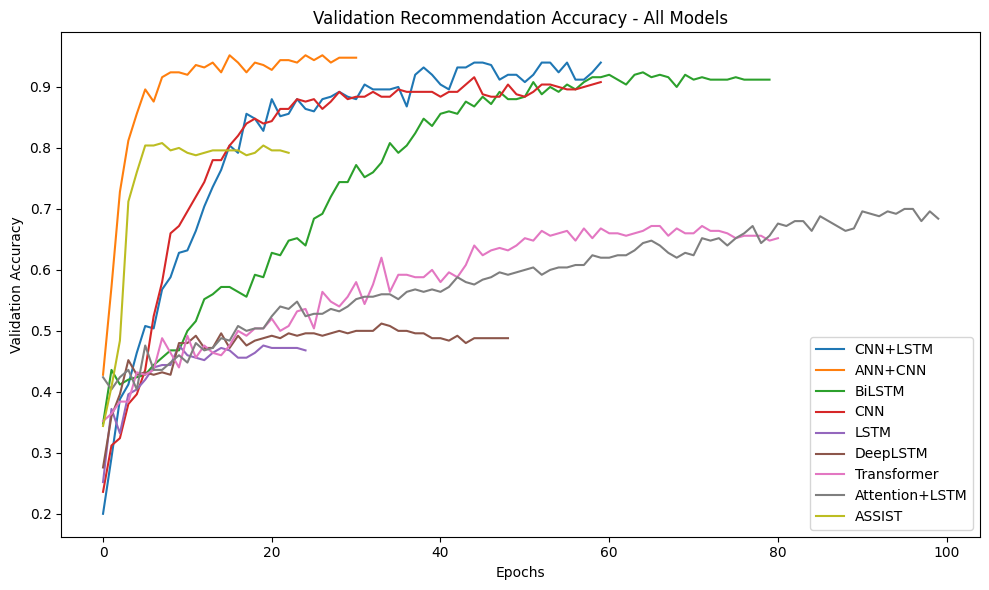


Best model based on Accuracy: ANN+CNN

Predictions on 3 rows using best model:
     pred_next_semester_CGPA pred_recommendation
93                  2.490436         Medium Risk
460                 1.731266           High Risk
418                 2.708082         Medium Risk


In [ ]:
import os
import random
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    balanced_accuracy_score, cohen_kappa_score, matthews_corrcoef,
    classification_report, mean_absolute_error,
    mean_squared_error, r2_score
)

from tensorflow.keras.layers import (
    Input, Dense, Dropout, Conv1D, MaxPooling1D, LSTM, Bidirectional,
    Flatten, Concatenate, GlobalMaxPooling1D,
    MultiHeadAttention, LayerNormalization, Add, GlobalAveragePooling1D,
    Layer
)
from tensorflow.keras.models import Model
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)
tf.random.set_seed(SEED)

try:
    for g in tf.config.list_physical_devices("GPU"):
        tf.config.experimental.set_memory_growth(g, True)
except Exception:
    pass

# Config
DATA_PATH = "student_dataset_final_preprocessed.csv"
EPOCHS = 100
BATCH_SIZE = 64
TEST_SIZE = 0.15
VAL_SIZE = 0.15

label_map = {
    0: "Low Risk",
    1: "Medium Risk",
    2: "High Risk",
    3: "Probation",
    4: "Dropout"
}
num_classes = 5
class_names = [label_map[i] for i in range(num_classes)]

# Load dataset
df = pd.read_csv(DATA_PATH)
print("Loaded dataset shape:", df.shape)

feature_cols = [
    "course1_marks", "course2_marks", "course3_marks",
    "course4_marks", "course5_marks",
    "currentCGPA", "previousCGPA", "semester",
    "totalcredithours", "attendanceRate", "studyHours"
]

required_cols = feature_cols + ["next_semester_CGPA", "recommendation"]
missing_cols = [c for c in required_cols if c not in df.columns]
if missing_cols:
    raise ValueError(f"Missing required columns in dataset: {missing_cols}")

X = df[feature_cols].copy()
y_cgpa = df["next_semester_CGPA"].astype(float).copy()
y_reco = df["recommendation"].astype(int).copy()

print("X shape:", X.shape)
print("y_cgpa shape:", y_cgpa.shape)
print("y_reco shape:", y_reco.shape)

print("\nRecommendation class distribution:")
print(y_reco.value_counts().sort_index())

temp_size = TEST_SIZE + VAL_SIZE

X_train, X_temp, y_cgpa_train, y_cgpa_temp, y_reco_train, y_reco_temp = train_test_split(
    X, y_cgpa, y_reco,
    test_size=temp_size,
    random_state=SEED,
    stratify=y_reco
)

relative_test_size = TEST_SIZE / (TEST_SIZE + VAL_SIZE)

X_val, X_test, y_cgpa_val, y_cgpa_test, y_reco_val, y_reco_test = train_test_split(
    X_temp, y_cgpa_temp, y_reco_temp,
    test_size=relative_test_size,
    random_state=SEED,
    stratify=y_reco_temp
)

y_reco_cat_train = to_categorical(y_reco_train, num_classes=num_classes)
y_reco_cat_val   = to_categorical(y_reco_val,   num_classes=num_classes)
y_reco_cat_test  = to_categorical(y_reco_test,  num_classes=num_classes)

X_train_scaled = X_train.values.astype(np.float32)
X_val_scaled   = X_val.values.astype(np.float32)
X_test_scaled  = X_test.values.astype(np.float32)

def to_3d(X2D):
    return X2D.reshape((X2D.shape[0], X2D.shape[1], 1)).astype(np.float32)

X_train_3d = to_3d(X_train_scaled)
X_val_3d   = to_3d(X_val_scaled)
X_test_3d  = to_3d(X_test_scaled)

print("\n3D input shape:", X_train_3d.shape)

# ASSIST model
academic_cols = [
    "course1_marks", "course2_marks", "course3_marks",
    "course4_marks", "course5_marks"
]
progress_cols = [
    "currentCGPA", "previousCGPA", "semester", "totalcredithours"
]
behaviour_cols = [
    "attendanceRate", "studyHours"
]
assessment_cols = [
    "avg_course_marks", "currentCGPA"
]

def make_assist_inputs(df_part: pd.DataFrame):
    temp = df_part.copy()
    temp["avg_course_marks"] = temp[academic_cols].mean(axis=1)

    X_academic = temp[academic_cols].values.astype(np.float32)
    X_progress = temp[progress_cols].values.astype(np.float32)
    X_behaviour = temp[behaviour_cols].values.astype(np.float32)
    X_assessment = temp[assessment_cols].values.astype(np.float32)

    X_academic_seq = X_academic.reshape((X_academic.shape[0], X_academic.shape[1], 1))
    X_progress_seq = X_progress.reshape((X_progress.shape[0], X_progress.shape[1], 1))
    X_behaviour_seq = X_behaviour.reshape((X_behaviour.shape[0], X_behaviour.shape[1], 1))

    return {
        "academic": X_academic_seq,
        "progress": X_progress_seq,
        "behaviour": X_behaviour_seq,
        "assessment": X_assessment
    }

assist_train = make_assist_inputs(X_train)
assist_val   = make_assist_inputs(X_val)
assist_test  = make_assist_inputs(X_test)

print("\nASSIST-inspired branch shapes:")
print("Academic   :", assist_train["academic"].shape)
print("Progress   :", assist_train["progress"].shape)
print("Behaviour  :", assist_train["behaviour"].shape)
print("Assessment :", assist_train["assessment"].shape)

def compile_model(
    model,
    learning_rate=7e-4,
    cgpa_loss_weight=0.3,
    reco_loss_weight=1.0
):
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss={
            "cgpa_output": "mse",
            "reco_output": "categorical_crossentropy"
        },
        loss_weights={
            "cgpa_output": cgpa_loss_weight,
            "reco_output": reco_loss_weight
        },
        metrics={
            "cgpa_output": ["mae"],
            "reco_output": ["accuracy"]
        }
    )
    return model

BASELINE_CFG = {
    "conv_filters": 64,
    "lstm_units": 64,
    "dense_units": 96,
    "dropout_rate": 0.25,
    "learning_rate": 1e-3,
    "cgpa_loss_weight": 1.0,
    "reco_loss_weight": 1.0,
    "use_extra_dense": False
}

# ASSIST attention layer
class TemporalAttention(Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    def build(self, input_shape):
        self.W = self.add_weight(
            name="att_weight",
            shape=(input_shape[-1], 1),
            initializer="glorot_uniform",
            trainable=True
        )
        self.b = self.add_weight(
            name="att_bias",
            shape=(input_shape[1], 1),
            initializer="zeros",
            trainable=True
        )
        super().build(input_shape)

    def call(self, x):
        e = tf.keras.backend.tanh(tf.tensordot(x, self.W, axes=1) + self.b)
        a = tf.keras.backend.softmax(e, axis=1)
        out = x * a
        return tf.keras.backend.sum(out, axis=1)

def build_bilstm_attention_branch(input_shape, name_prefix, units=32, dropout=0.2):
    inp = Input(shape=input_shape, name=f"{name_prefix}_input")
    x = Bidirectional(
        LSTM(units, return_sequences=True, dropout=dropout),
        name=f"{name_prefix}_bilstm"
    )(inp)
    x = TemporalAttention(name=f"{name_prefix}_attention")(x)
    x = Dense(32, activation="relu", name=f"{name_prefix}_dense")(x)
    return inp, x

# Model builders
def build_cnn_lstm(n_features, n_classes):
    # stronger_cnn_lstm
    inp = Input(shape=(n_features, 1))
    x = Conv1D(128, 3, activation="relu", padding="same")(inp)
    x = MaxPooling1D(2)(x)
    x = Dropout(0.20)(x)

    x = LSTM(96, return_sequences=False)(x)
    x = Dropout(0.20)(x)

    shared = Dense(128, activation="relu")(x)
    shared = Dropout(0.20)(shared)
    shared = Dense(64, activation="relu")(shared)

    out_cgpa = Dense(1, activation="linear", name="cgpa_output")(shared)
    out_reco = Dense(n_classes, activation="softmax", name="reco_output")(shared)

    model = Model(inp, [out_cgpa, out_reco], name="CNN_LSTM")
    return compile_model(
        model,
        learning_rate=7e-4,
        cgpa_loss_weight=0.3,
        reco_loss_weight=1.0
    )

def build_cnn(n_features, n_classes):
    conv_filters = BASELINE_CFG["conv_filters"]
    dense_units = BASELINE_CFG["dense_units"]
    dropout_rate = BASELINE_CFG["dropout_rate"]

    inp = Input(shape=(n_features, 1))
    x = Conv1D(conv_filters, 3, activation="relu", padding="same")(inp)
    x = MaxPooling1D(2)(x)
    x = Dropout(dropout_rate)(x)

    x = Conv1D(conv_filters, 3, activation="relu", padding="same")(x)
    x = GlobalMaxPooling1D()(x)
    x = Dropout(dropout_rate)(x)

    shared = Dense(dense_units, activation="relu")(x)

    out_cgpa = Dense(1, activation="linear", name="cgpa_output")(shared)
    out_reco = Dense(n_classes, activation="softmax", name="reco_output")(shared)

    model = Model(inp, [out_cgpa, out_reco], name="CNN")
    return compile_model(
        model,
        learning_rate=BASELINE_CFG["learning_rate"],
        cgpa_loss_weight=BASELINE_CFG["cgpa_loss_weight"],
        reco_loss_weight=BASELINE_CFG["reco_loss_weight"]
    )

def build_lstm(n_features, n_classes):
    lstm_units = BASELINE_CFG["lstm_units"]
    dense_units = BASELINE_CFG["dense_units"]
    dropout_rate = BASELINE_CFG["dropout_rate"]

    inp = Input(shape=(n_features, 1))
    x = LSTM(lstm_units, return_sequences=False)(inp)
    x = Dropout(dropout_rate)(x)

    shared = Dense(dense_units, activation="relu")(x)

    out_cgpa = Dense(1, activation="linear", name="cgpa_output")(shared)
    out_reco = Dense(n_classes, activation="softmax", name="reco_output")(shared)

    model = Model(inp, [out_cgpa, out_reco], name="LSTM")
    return compile_model(
        model,
        learning_rate=BASELINE_CFG["learning_rate"],
        cgpa_loss_weight=BASELINE_CFG["cgpa_loss_weight"],
        reco_loss_weight=BASELINE_CFG["reco_loss_weight"]
    )

def build_bilstm(n_features, n_classes):
    inp = Input(shape=(n_features, 1))
    x = Bidirectional(LSTM(96, return_sequences=False))(inp)
    x = Dropout(0.20)(x)

    shared = Dense(128, activation="relu")(x)
    shared = Dropout(0.20)(shared)
    shared = Dense(64, activation="relu")(shared)

    out_cgpa = Dense(1, activation="linear", name="cgpa_output")(shared)
    out_reco = Dense(n_classes, activation="softmax", name="reco_output")(shared)

    model = Model(inp, [out_cgpa, out_reco], name="BiLSTM")
    return compile_model(model)

def build_deep_lstm(n_features, n_classes):
    inp = Input(shape=(n_features, 1))
    x = LSTM(128, return_sequences=True)(inp)
    x = Dropout(0.20)(x)
    x = LSTM(96, return_sequences=False)(x)
    x = Dropout(0.20)(x)

    shared = Dense(128, activation="relu")(x)
    shared = Dropout(0.20)(shared)
    shared = Dense(64, activation="relu")(shared)

    out_cgpa = Dense(1, activation="linear", name="cgpa_output")(shared)
    out_reco = Dense(n_classes, activation="softmax", name="reco_output")(shared)

    model = Model(inp, [out_cgpa, out_reco], name="DeepLSTM")
    return compile_model(model)

def build_attention_lstm(n_features, n_classes):
    inp = Input(shape=(n_features, 1))
    x = LSTM(96, return_sequences=True)(inp)

    d_model = 128
    x_proj = Dense(d_model)(x)
    attn = MultiHeadAttention(num_heads=4, key_dim=32)(x_proj, x_proj)
    x = Add()([x_proj, attn])
    x = LayerNormalization()(x)
    x = GlobalAveragePooling1D()(x)
    x = Dropout(0.20)(x)

    shared = Dense(128, activation="relu")(x)
    shared = Dropout(0.20)(shared)
    shared = Dense(64, activation="relu")(shared)

    out_cgpa = Dense(1, activation="linear", name="cgpa_output")(shared)
    out_reco = Dense(n_classes, activation="softmax", name="reco_output")(shared)

    model = Model(inp, [out_cgpa, out_reco], name="Attention_LSTM")
    return compile_model(model)

def transformer_encoder_block(x, num_heads=4, key_dim=32, ff_dim=128, dropout=0.20):
    attn_out = MultiHeadAttention(num_heads=num_heads, key_dim=key_dim)(x, x)
    x = Add()([x, attn_out])
    x = LayerNormalization()(x)

    ff = Dense(ff_dim, activation="relu")(x)
    ff = Dropout(dropout)(ff)
    ff = Dense(x.shape[-1])(ff)
    x = Add()([x, ff])
    x = LayerNormalization()(x)
    return x

def build_transformer(n_features, n_classes):
    inp = Input(shape=(n_features, 1))
    x = Dense(128)(inp)
    x = transformer_encoder_block(x, num_heads=4, key_dim=32, ff_dim=128, dropout=0.20)
    x = transformer_encoder_block(x, num_heads=4, key_dim=32, ff_dim=128, dropout=0.20)
    x = GlobalAveragePooling1D()(x)
    x = Dropout(0.20)(x)

    shared = Dense(128, activation="relu")(x)
    shared = Dropout(0.20)(shared)
    shared = Dense(64, activation="relu")(shared)

    out_cgpa = Dense(1, activation="linear", name="cgpa_output")(shared)
    out_reco = Dense(n_classes, activation="softmax", name="reco_output")(shared)

    model = Model(inp, [out_cgpa, out_reco], name="Transformer")
    return compile_model(model)

def build_ann_cnn(n_features, n_classes):
    cnn_inp = Input(shape=(n_features, 1), name="cnn_input")
    c = Conv1D(128, 3, activation="relu", padding="same")(cnn_inp)
    c = MaxPooling1D(2)(c)
    c = Dropout(0.20)(c)
    c = Flatten()(c)
    c = Dense(128, activation="relu")(c)
    c = Dropout(0.20)(c)
    c = Dense(64, activation="relu")(c)

    ann_inp = Input(shape=(n_features,), name="ann_input")
    a = Dense(128, activation="relu")(ann_inp)
    a = Dropout(0.20)(a)
    a = Dense(64, activation="relu")(a)

    merged = Concatenate()([c, a])
    shared = Dense(128, activation="relu")(merged)
    shared = Dropout(0.20)(shared)
    shared = Dense(64, activation="relu")(shared)

    out_cgpa = Dense(1, activation="linear", name="cgpa_output")(shared)
    out_reco = Dense(n_classes, activation="softmax", name="reco_output")(shared)

    model = Model([cnn_inp, ann_inp], [out_cgpa, out_reco], name="ANN_CNN")
    return compile_model(
        model,
        learning_rate=7e-4,
        cgpa_loss_weight=0.3,
        reco_loss_weight=1.0
    )

def build_assist_model(n_classes):
    academic_inp, academic_feat = build_bilstm_attention_branch(
        input_shape=(len(academic_cols), 1),
        name_prefix="academic",
        units=32,
        dropout=0.2
    )

    progress_inp, progress_feat = build_bilstm_attention_branch(
        input_shape=(len(progress_cols), 1),
        name_prefix="progress",
        units=32,
        dropout=0.2
    )

    behaviour_inp, behaviour_feat = build_bilstm_attention_branch(
        input_shape=(len(behaviour_cols), 1),
        name_prefix="behaviour",
        units=16,
        dropout=0.2
    )

    assessment_inp = Input(shape=(len(assessment_cols),), name="assessment_input")
    assessment_feat = Dense(16, activation="relu", name="assessment_dense")(assessment_inp)

    merged = Concatenate(name="assist_concat_layer")([
        academic_feat,
        progress_feat,
        behaviour_feat,
        assessment_feat
    ])

    x = Dense(128, activation="relu", name="assist_fusion_dense_1")(merged)
    x = Dropout(0.2, name="assist_fusion_dropout_1")(x)
    x = Dense(64, activation="relu", name="assist_fusion_dense_2")(x)

    out_cgpa = Dense(1, activation="linear", name="cgpa_output")(x)
    out_reco = Dense(n_classes, activation="softmax", name="reco_output")(x)

    model = Model(
        inputs=[academic_inp, progress_inp, behaviour_inp, assessment_inp],
        outputs=[out_cgpa, out_reco],
        name="ASSIST_Model"
    )
    return compile_model(
        model,
        learning_rate=7e-4,
        cgpa_loss_weight=0.3,
        reco_loss_weight=1.0
    )

# Callbacks
def make_callbacks():
    return [
        EarlyStopping(
            monitor="val_reco_output_accuracy",
            patience=15,
            mode="max",
            restore_best_weights=True
        ),
        ReduceLROnPlateau(
            monitor="val_reco_output_accuracy",
            factor=0.5,
            patience=5,
            min_lr=1e-6,
            mode="max"
        )
    ]

# Train/predict helpers
def fit_model(model, model_key):
    callbacks = make_callbacks()
    n_inputs = len(model.inputs)

    if n_inputs == 4 and model_key == "ASSIST":
        history = model.fit(
            [
                assist_train["academic"],
                assist_train["progress"],
                assist_train["behaviour"],
                assist_train["assessment"]
            ],
            {
                "cgpa_output": y_cgpa_train.values,
                "reco_output": y_reco_cat_train
            },
            validation_data=(
                [
                    assist_val["academic"],
                    assist_val["progress"],
                    assist_val["behaviour"],
                    assist_val["assessment"]
                ],
                {
                    "cgpa_output": y_cgpa_val.values,
                    "reco_output": y_reco_cat_val
                }
            ),
            epochs=EPOCHS,
            batch_size=BATCH_SIZE,
            callbacks=callbacks,
            verbose=1
        )
    elif n_inputs == 2:
        history = model.fit(
            [X_train_3d, X_train_scaled],
            {
                "cgpa_output": y_cgpa_train.values,
                "reco_output": y_reco_cat_train
            },
            validation_data=(
                [X_val_3d, X_val_scaled],
                {
                    "cgpa_output": y_cgpa_val.values,
                    "reco_output": y_reco_cat_val
                }
            ),
            epochs=EPOCHS,
            batch_size=BATCH_SIZE,
            callbacks=callbacks,
            verbose=1
        )
    else:
        history = model.fit(
            X_train_3d,
            {
                "cgpa_output": y_cgpa_train.values,
                "reco_output": y_reco_cat_train
            },
            validation_data=(
                X_val_3d,
                {
                    "cgpa_output": y_cgpa_val.values,
                    "reco_output": y_reco_cat_val
                }
            ),
            epochs=EPOCHS,
            batch_size=BATCH_SIZE,
            callbacks=callbacks,
            verbose=1
        )
    return history

def predict_model(model, model_key):
    n_inputs = len(model.inputs)

    if n_inputs == 4 and model_key == "ASSIST":
        pred_cgpa, pred_probs = model.predict(
            [
                assist_test["academic"],
                assist_test["progress"],
                assist_test["behaviour"],
                assist_test["assessment"]
            ],
            verbose=0
        )
    elif n_inputs == 2:
        pred_cgpa, pred_probs = model.predict([X_test_3d, X_test_scaled], verbose=0)
    else:
        pred_cgpa, pred_probs = model.predict(X_test_3d, verbose=0)

    return pred_cgpa.flatten(), pred_probs

def rmse_score(y_true, y_pred):
    try:
        return mean_squared_error(y_true, y_pred, squared=False)
    except TypeError:
        return np.sqrt(mean_squared_error(y_true, y_pred))

def evaluate_model(display_name, y_true_cls, y_pred_cls, y_true_cgpa, y_pred_cgpa):
    acc  = accuracy_score(y_true_cls, y_pred_cls)
    prec = precision_score(y_true_cls, y_pred_cls, average="weighted", zero_division=0)
    rec  = recall_score(y_true_cls, y_pred_cls, average="weighted", zero_division=0)
    f1   = f1_score(y_true_cls, y_pred_cls, average="weighted", zero_division=0)
    bal_acc = balanced_accuracy_score(y_true_cls, y_pred_cls)
    kappa = cohen_kappa_score(y_true_cls, y_pred_cls)
    mcc = matthews_corrcoef(y_true_cls, y_pred_cls)

    mae = mean_absolute_error(y_true_cgpa, y_pred_cgpa)
    rmse = rmse_score(y_true_cgpa, y_pred_cgpa)
    r2 = r2_score(y_true_cgpa, y_pred_cgpa)

    print("\n" + "=" * 70)
    print(f"{display_name} - Classification")
    print("=" * 70)
    print(f"Accuracy          : {acc:.4f}")
    print(f"Precision         : {prec:.4f}")
    print(f"Recall            : {rec:.4f}")
    print(f"F1-score          : {f1:.4f}")
    print(f"Balanced Accuracy : {bal_acc:.4f}")
    print(f"Cohen's Kappa     : {kappa:.4f}")
    print(f"MCC               : {mcc:.4f}")

    print("\nClassification Report:\n")
    print(classification_report(
        y_true_cls, y_pred_cls,
        labels=np.arange(num_classes),
        target_names=class_names,
        zero_division=0,
        digits=4
    ))

    print(f"{display_name} - Regression")
    print(f"MAE               : {mae:.4f}")
    print(f"RMSE              : {rmse:.4f}")
    print(f"R2                : {r2:.4f}")

    return {
        "Model": display_name,
        "Accuracy": acc,
        "Precision_w": prec,
        "Recall_w": rec,
        "F1_w": f1,
        "Balanced_Accuracy": bal_acc,
        "Kappa": kappa,
        "MCC": mcc,
        "CGPA_MAE": mae,
        "CGPA_RMSE": rmse,
        "CGPA_R2": r2
    }

# Models comparison
MODEL_BUILDERS = {
    "CNN_LSTM": build_cnn_lstm,
    "ANN_CNN": build_ann_cnn,
    "BiLSTM": build_bilstm,
    "CNN": build_cnn,
    "LSTM": build_lstm,
    "DeepLSTM": build_deep_lstm,
    "Transformer": build_transformer,
    "Attention_LSTM": build_attention_lstm,
    "ASSIST": build_assist_model
}

DISPLAY_NAMES = {
    "CNN_LSTM": "CNN+LSTM",
    "ANN_CNN": "ANN+CNN",
    "BiLSTM": "BiLSTM",
    "CNN": "CNN",
    "LSTM": "LSTM",
    "DeepLSTM": "DeepLSTM",
    "Transformer": "Transformer",
    "Attention_LSTM": "Attention+LSTM",
    "ASSIST": "ASSIST"
}

results = []
histories = {}
trained_models = {}

for model_key, builder in MODEL_BUILDERS.items():
    display_name = DISPLAY_NAMES[model_key]

    print("\n" + "#" * 80)
    print(f"Training model: {display_name}")
    print("#" * 80)

    tf.keras.backend.clear_session()
    tf.random.set_seed(SEED)
    np.random.seed(SEED)
    random.seed(SEED)

    if model_key == "ASSIST":
        model = builder(num_classes)
    else:
        model = builder(X_train_3d.shape[1], num_classes)

    model.summary()

    history = fit_model(model, model_key)
    histories[display_name] = history.history
    trained_models[display_name] = model

    pred_cgpa, pred_reco_probs = predict_model(model, model_key)
    pred_reco_idx = np.argmax(pred_reco_probs, axis=1)

    result_row = evaluate_model(
        display_name=display_name,
        y_true_cls=y_reco_test.values,
        y_pred_cls=pred_reco_idx,
        y_true_cgpa=y_cgpa_test.values,
        y_pred_cgpa=pred_cgpa
    )
    results.append(result_row)

results_df = pd.DataFrame(results).sort_values(by="Accuracy", ascending=False).reset_index(drop=True)

print("\n" + "=" * 90)
print("FINAL MODEL COMPARISON")
print("=" * 90)
print(results_df.to_string(index=False))

results_df.to_csv("model_comparison_multitask_with_assist.csv", index=False)
print("\nSaved: model_comparison_multitask_with_assist.csv")

def plot_metric_bar(df_results, metric_col, title, ylabel):
    plt.figure(figsize=(10, 5))
    plt.bar(df_results["Model"], df_results[metric_col])
    plt.xticks(rotation=45, ha="right")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.tight_layout()
    plt.show()

plot_metric_bar(results_df, "Accuracy", "Model Comparison - Accuracy", "Accuracy")
plot_metric_bar(results_df, "F1_w", "Model Comparison - Weighted F1", "Weighted F1")
plot_metric_bar(results_df, "Balanced_Accuracy", "Model Comparison - Balanced Accuracy", "Balanced Accuracy")
plot_metric_bar(results_df, "CGPA_MAE", "Model Comparison - CGPA MAE", "MAE")
plot_metric_bar(results_df, "CGPA_RMSE", "Model Comparison - CGPA RMSE", "RMSE")
plot_metric_bar(results_df, "CGPA_R2", "Model Comparison - CGPA R²", "R²")

plt.figure(figsize=(10, 6))
for model_name, hist in histories.items():
    if "val_reco_output_accuracy" in hist:
        plt.plot(hist["val_reco_output_accuracy"], label=model_name)
plt.xlabel("Epochs")
plt.ylabel("Validation Accuracy")
plt.title("Validation Recommendation Accuracy - All Models")
plt.legend()
plt.tight_layout()
plt.show()

best_model_name = results_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]

print(f"\nBest model based on Accuracy: {best_model_name}")

def predict_next_semester(df_new: pd.DataFrame, model_name=None):
    if model_name is None:
        model_name = best_model_name

    model = trained_models[model_name]

    missing = [c for c in feature_cols if c not in df_new.columns]
    if missing:
        raise ValueError(f"Missing required feature columns: {missing}")

    x2d = df_new[feature_cols].astype(float).values.astype(np.float32)
    x3d = to_3d(x2d)

    if model_name == "ASSIST-Inspired":
        temp = df_new.copy()
        temp["avg_course_marks"] = temp[academic_cols].mean(axis=1)

        x_academic = temp[academic_cols].values.astype(np.float32).reshape((-1, len(academic_cols), 1))
        x_progress = temp[progress_cols].values.astype(np.float32).reshape((-1, len(progress_cols), 1))
        x_behaviour = temp[behaviour_cols].values.astype(np.float32).reshape((-1, len(behaviour_cols), 1))
        x_assessment = temp[assessment_cols].values.astype(np.float32)

        cgpa_pred, reco_probs = model.predict(
            [x_academic, x_progress, x_behaviour, x_assessment],
            verbose=0
        )
    elif len(model.inputs) == 2:
        cgpa_pred, reco_probs = model.predict([x3d, x2d], verbose=0)
    else:
        cgpa_pred, reco_probs = model.predict(x3d, verbose=0)

    reco_idx = np.argmax(reco_probs, axis=1)

    return pd.DataFrame({
        "pred_next_semester_CGPA": cgpa_pred.flatten(),
        "pred_recommendation": [label_map[i] for i in reco_idx]
    }, index=df_new.index)

demo_new = X_test.iloc[:3].copy()
print("\nPredictions on 3 rows using best model:")
print(predict_next_semester(demo_new))

Save ANN+CNN history

In [ ]:
history_anncnn = history
y_true_reco_anncnn = np.asarray(y_reco_test)
y_pred_reco_anncnn = np.asarray(pred_reco_idx)
pred_reco_probs_anncnn = np.asarray(pred_reco_probs)

y_cgpa_test_anncnn = np.asarray(y_cgpa_test)
y_pred_cgpa_anncnn = np.asarray(pred_cgpa).flatten()

Train / Val Accuracy plot - ANN+CNN

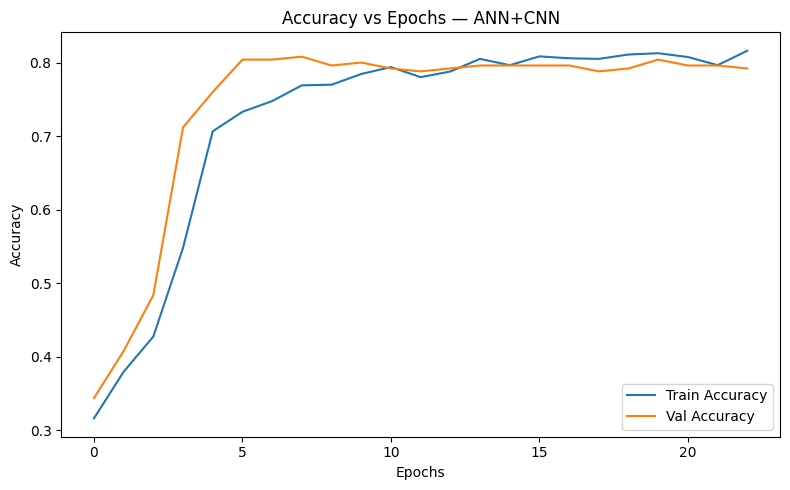

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(history_anncnn.history["reco_output_accuracy"], label="Train Accuracy")
plt.plot(history_anncnn.history["val_reco_output_accuracy"], label="Val Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Epochs — ANN+CNN")
plt.legend()
plt.tight_layout()
plt.show()

Tran / Val CGPA Model Loss plot - ANN+CNN

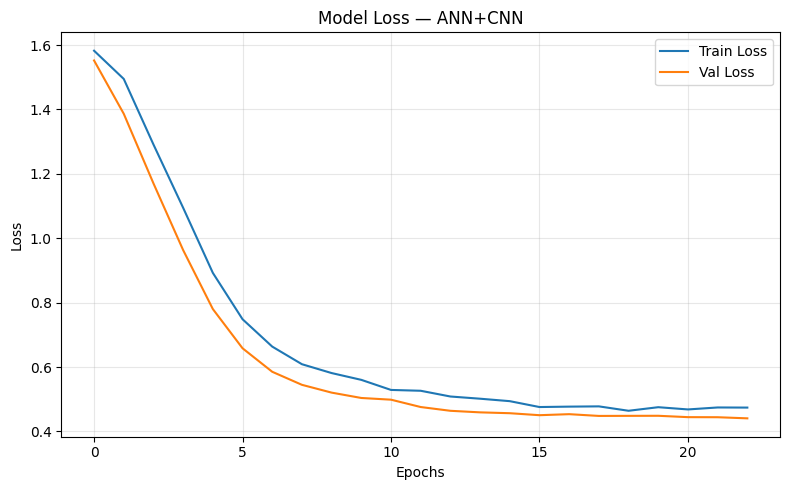

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    history_anncnn.history["reco_output_loss"],
    label="Train Loss"
)

plt.plot(
    history_anncnn.history["val_reco_output_loss"],
    label="Val Loss"
)

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Model Loss — ANN+CNN")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

CGPA Model Loss plot - ANN+CNN

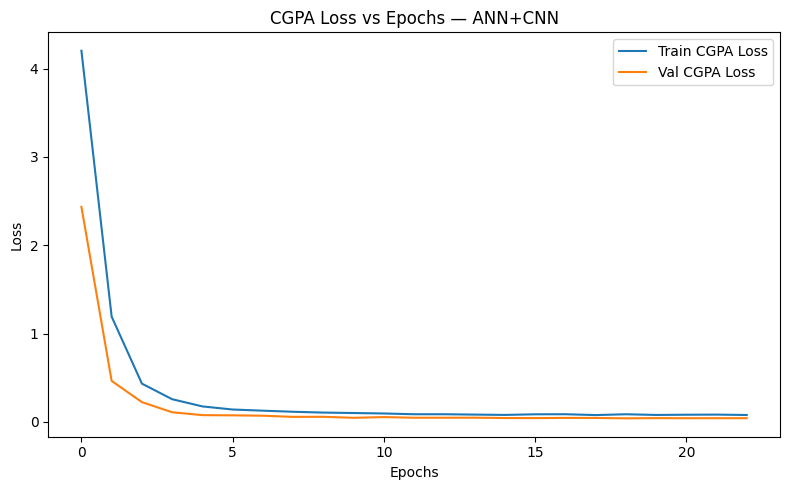

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(history_anncnn.history["cgpa_output_loss"], label="Train CGPA Loss")
plt.plot(history_anncnn.history["val_cgpa_output_loss"], label="Val CGPA Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("CGPA Loss vs Epochs — ANN+CNN")
plt.legend()
plt.tight_layout()
plt.show()

MSE loss plot - ANN+CNN

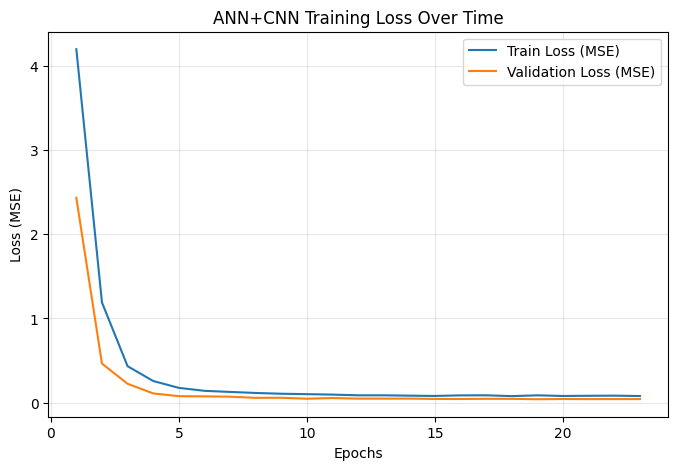

In [ ]:
import matplotlib.pyplot as plt

train_loss = history_anncnn.history["cgpa_output_loss"]
val_loss   = history_anncnn.history["val_cgpa_output_loss"]

train_mae = history_anncnn.history["cgpa_output_mae"]
val_mae   = history_anncnn.history["val_cgpa_output_mae"]

epochs = range(1, len(train_loss) + 1)

plt.figure(figsize=(8, 5))

# Loss (MSE)

plt.plot(epochs, train_loss, label="Train Loss (MSE)")
plt.plot(epochs, val_loss, label="Validation Loss (MSE)")

plt.xlabel("Epochs")
plt.ylabel("Loss (MSE)")
plt.title("ANN+CNN Training Loss Over Time")
plt.legend()
plt.grid(True, alpha=0.3)

MAE Model loss plot - ANN+CNN

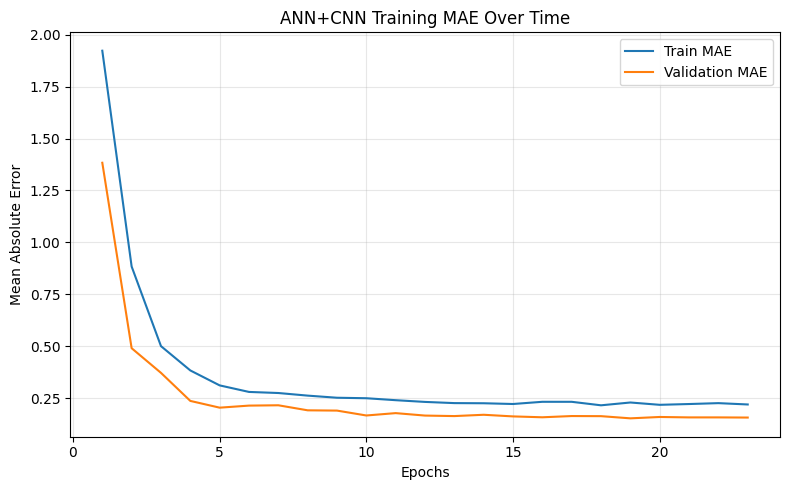

In [ ]:
# MAE
plt.figure(figsize=(8, 5))

plt.plot(epochs, train_mae, label="Train MAE")
plt.plot(epochs, val_mae, label="Validation MAE")

plt.xlabel("Epochs")
plt.ylabel("Mean Absolute Error")
plt.title("ANN+CNN Training MAE Over Time")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Precision-Recall Curve plot - ANN+CNN

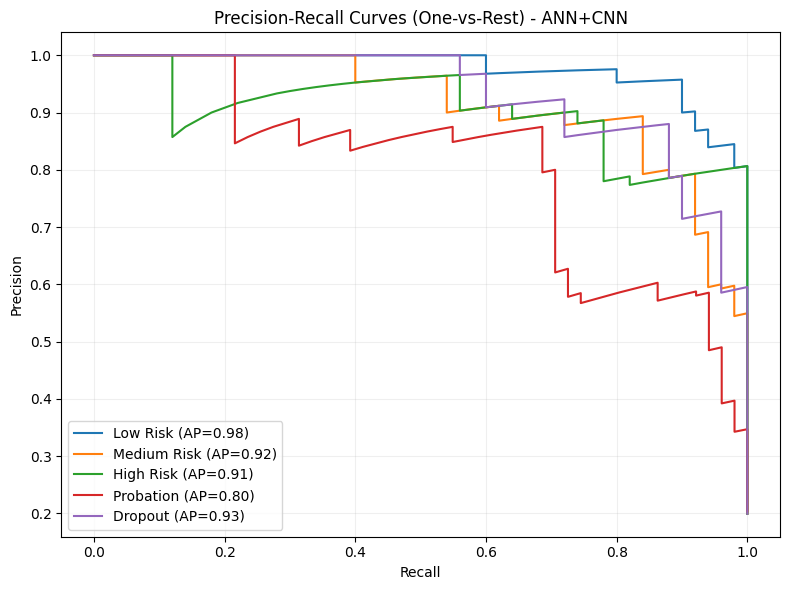

Per-class Average Precision:
Low Risk: 0.9754
Medium Risk: 0.9153
High Risk: 0.9061
Probation: 0.8022
Dropout: 0.9317

Macro Average Precision: 0.9061


In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import precision_recall_curve, average_precision_score
import numpy as np
import matplotlib.pyplot as plt

y_true_reco_arr = np.asarray(y_true_reco_anncnn, dtype=int)
pred_reco_probs_arr = np.asarray(pred_reco_probs_anncnn, dtype=float)

classes = np.arange(num_classes)
Y_true_bin = label_binarize(y_true_reco_arr, classes=classes)

ap_scores = []
plt.figure(figsize=(8, 6))

for c in range(num_classes):
    y_true_c = Y_true_bin[:, c]
    y_score_c = pred_reco_probs_arr[:, c]

    precision_c, recall_c, _ = precision_recall_curve(y_true_c, y_score_c)
    ap_c = average_precision_score(y_true_c, y_score_c)
    ap_scores.append(ap_c)

    plt.plot(recall_c, precision_c, label=f"{class_names[c]} (AP={ap_c:.2f})")

macro_ap = np.mean(ap_scores)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves (One-vs-Rest) - ANN+CNN")
plt.legend()
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

print("Per-class Average Precision:")
for c, ap_c in enumerate(ap_scores):
    print(f"{class_names[c]}: {ap_c:.4f}")

print(f"\nMacro Average Precision: {macro_ap:.4f}")

ROC Curves plot - ANN+CNN

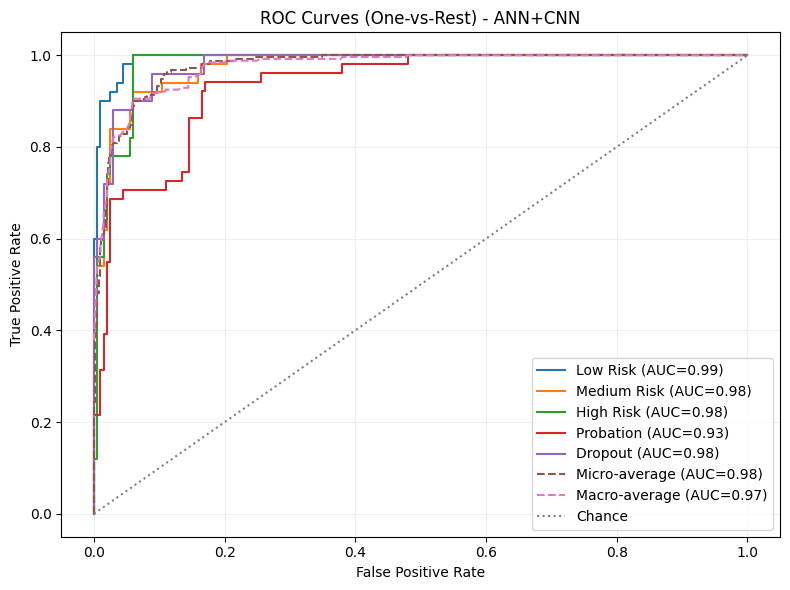

Per-class ROC-AUC:
Low Risk: 0.9938
Medium Risk: 0.9759
High Risk: 0.9807
Probation: 0.9336
Dropout: 0.9799

Micro-average ROC-AUC: 0.9759
Macro-average ROC-AUC: 0.9740

ROC-AUC Results Table:
           Class   ROC_AUC
0       Low Risk  0.993831
1    Medium Risk  0.975920
2      High Risk  0.980697
3      Probation  0.933627
4        Dropout  0.979900
5  Micro-average  0.975933
6  Macro-average  0.973999


In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

y_true_reco_arr = np.asarray(y_true_reco_anncnn, dtype=int)
pred_reco_probs_arr = np.asarray(pred_reco_probs_anncnn, dtype=float)

classes = np.arange(num_classes)
Y_true_bin = label_binarize(y_true_reco_arr, classes=classes)

fpr = {}
tpr = {}
roc_auc = {}

for c in range(num_classes):
    fpr[c], tpr[c], _ = roc_curve(Y_true_bin[:, c], pred_reco_probs_arr[:, c])
    roc_auc[c] = auc(fpr[c], tpr[c])

fpr["micro"], tpr["micro"], _ = roc_curve(Y_true_bin.ravel(), pred_reco_probs_arr.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

all_fpr = np.unique(np.concatenate([fpr[c] for c in range(num_classes)]))
mean_tpr = np.zeros_like(all_fpr)

for c in range(num_classes):
    mean_tpr += np.interp(all_fpr, fpr[c], tpr[c])

mean_tpr /= num_classes
fpr["macro"] = all_fpr
tpr["macro"] = mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

plt.figure(figsize=(8, 6))

for c in range(num_classes):
    plt.plot(fpr[c], tpr[c], label=f"{class_names[c]} (AUC={roc_auc[c]:.2f})")

plt.plot(
    fpr["micro"], tpr["micro"],
    linestyle="--",
    label=f"Micro-average (AUC={roc_auc['micro']:.2f})"
)

plt.plot(
    fpr["macro"], tpr["macro"],
    linestyle="--",
    label=f"Macro-average (AUC={roc_auc['macro']:.2f})"
)

plt.plot([0, 1], [0, 1], linestyle=":", label="Chance")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves (One-vs-Rest) - ANN+CNN")
plt.legend()
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

print("Per-class ROC-AUC:")
for c in range(num_classes):
    print(f"{class_names[c]}: {roc_auc[c]:.4f}")

print(f"\nMicro-average ROC-AUC: {roc_auc['micro']:.4f}")
print(f"Macro-average ROC-AUC: {roc_auc['macro']:.4f}")

roc_results_df = pd.DataFrame({
    "Class": class_names,
    "ROC_AUC": [roc_auc[c] for c in range(num_classes)]
})

roc_results_df.loc[len(roc_results_df)] = ["Micro-average", roc_auc["micro"]]
roc_results_df.loc[len(roc_results_df)] = ["Macro-average", roc_auc["macro"]]

print("\nROC-AUC Results Table:")
print(roc_results_df)

roc_results_df.to_csv("roc_auc_results_anncnn.csv", index=False)

Classification Confidence plot - ANN+CNN

Mean Confidence: 0.8870
Std Confidence : 0.1316


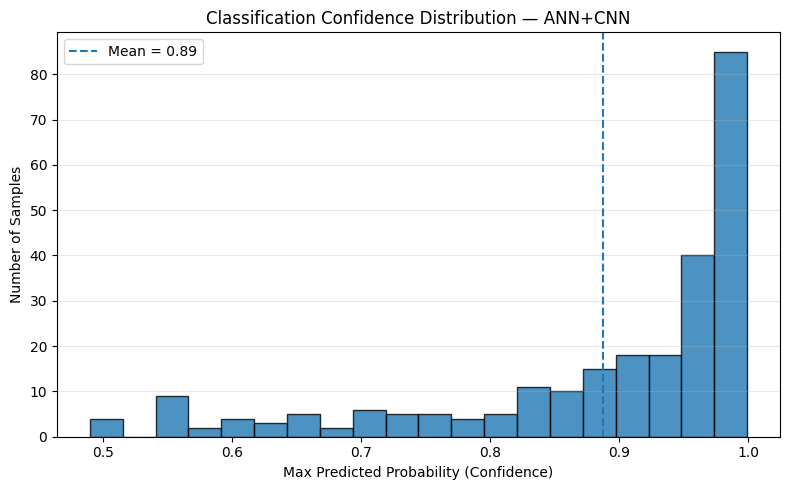

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

pred_reco_probs_arr = np.asarray(pred_reco_probs_anncnn, dtype=float)

cls_confidence = np.max(pred_reco_probs_arr, axis=1)

mean_conf = np.mean(cls_confidence)
std_conf  = np.std(cls_confidence)

print(f"Mean Confidence: {mean_conf:.4f}")
print(f"Std Confidence : {std_conf:.4f}")

plt.figure(figsize=(8, 5))
plt.hist(
    cls_confidence,
    bins=20,
    edgecolor="black",
    alpha=0.8
)

plt.axvline(mean_conf, linestyle="--", label=f"Mean = {mean_conf:.2f}")

plt.xlabel("Max Predicted Probability (Confidence)")
plt.ylabel("Number of Samples")
plt.title("Classification Confidence Distribution — ANN+CNN")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

Regression Confidence plot - ANN+CNN

Mean Regression Confidence: 0.9524
Std Regression Confidence : 0.0368


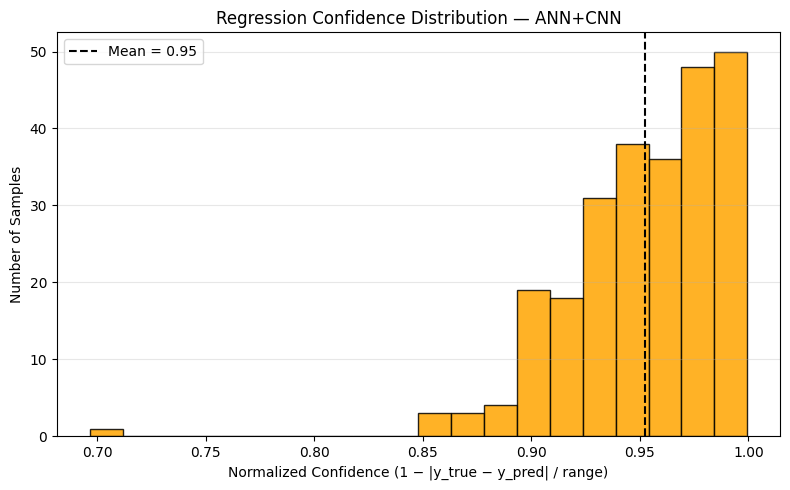

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

y_true_c = np.asarray(y_cgpa_test_anncnn, dtype=float)
y_pred_c = np.asarray(y_pred_cgpa_anncnn, dtype=float).flatten()

cgpa_range = np.max(y_true_c) - np.min(y_true_c)
cgpa_range = cgpa_range if cgpa_range != 0 else 1.0

reg_confidence = 1.0 - (np.abs(y_true_c - y_pred_c) / cgpa_range)
reg_confidence = np.clip(reg_confidence, 0, 1)

mean_conf = np.mean(reg_confidence)
std_conf  = np.std(reg_confidence)

print(f"Mean Regression Confidence: {mean_conf:.4f}")
print(f"Std Regression Confidence : {std_conf:.4f}")

plt.figure(figsize=(8, 5))
plt.hist(
    reg_confidence,
    bins=20,
    color="orange",
    edgecolor="black",
    alpha=0.85
)

plt.axvline(mean_conf, linestyle="--", color="black", label=f"Mean = {mean_conf:.2f}")

plt.xlabel("Normalized Confidence (1 − |y_true − y_pred| / range)")
plt.ylabel("Number of Samples")
plt.title("Regression Confidence Distribution — ANN+CNN")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

Predicted vs. True values plot - ANN+CNN

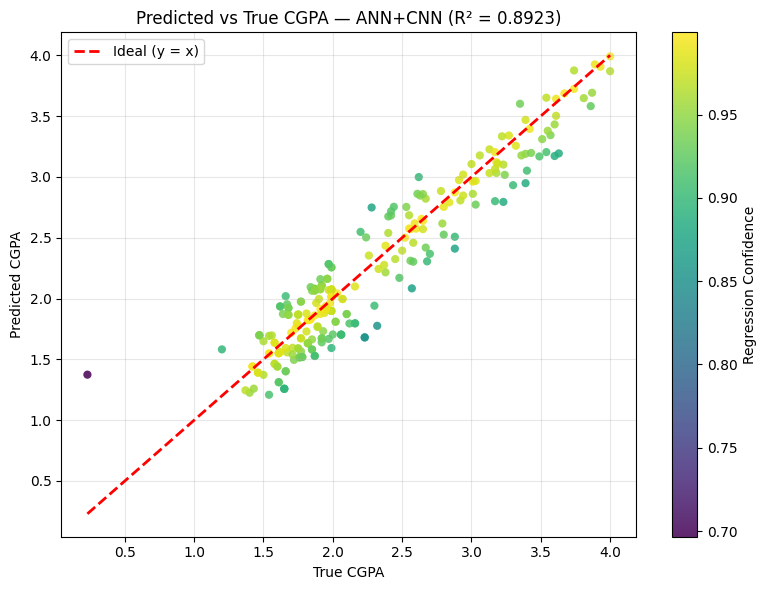

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

y_true_c = np.asarray(y_cgpa_test_anncnn, dtype=float)
y_pred_c = np.asarray(y_pred_cgpa_anncnn, dtype=float).flatten()

r2 = r2_score(y_true_c, y_pred_c)

cgpa_range = np.max(y_true_c) - np.min(y_true_c)
cgpa_range = cgpa_range if cgpa_range != 0 else 1.0

reg_confidence = 1.0 - (np.abs(y_true_c - y_pred_c) / cgpa_range)
reg_confidence = np.clip(reg_confidence, 0, 1)

plt.figure(figsize=(8, 6))

sc = plt.scatter(
    y_true_c,
    y_pred_c,
    c=reg_confidence,
    cmap="viridis",
    s=35,
    alpha=0.85,
    edgecolors="none"
)

min_cgpa = min(y_true_c.min(), y_pred_c.min())
max_cgpa = max(y_true_c.max(), y_pred_c.max())

plt.plot(
    [min_cgpa, max_cgpa],
    [min_cgpa, max_cgpa],
    linestyle="--",
    color="red",
    linewidth=2,
    label="Ideal (y = x)"
)

plt.xlabel("True CGPA")
plt.ylabel("Predicted CGPA")
plt.title(f"Predicted vs True CGPA — ANN+CNN (R² = {r2:.4f})")
plt.legend()
plt.grid(True, alpha=0.3)

cbar = plt.colorbar(sc)
cbar.set_label("Regression Confidence")

plt.tight_layout()
plt.show()

Predicted vs. Recommendation Confidence plot - ANN+CNN

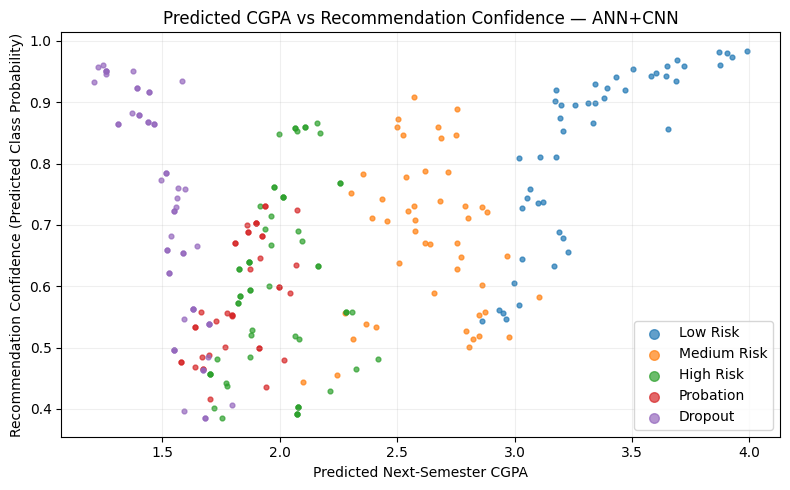

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

y_pred_cgpa_arr = np.asarray(y_pred_cgpa_anncnn, dtype=float).flatten()
y_pred_reco_arr = np.asarray(y_pred_reco_anncnn, dtype=int)
pred_reco_probs_arr = np.asarray(pred_reco_probs_anncnn, dtype=float)

plt.figure(figsize=(8, 5))

for c in range(num_classes):
    mask = (y_pred_reco_arr == c)

    if not np.any(mask):
        continue

    plt.scatter(
        y_pred_cgpa_arr[mask],
        pred_reco_probs_arr[mask, c],
        s=12,
        alpha=0.7,
        label=class_names[c]
    )

plt.xlabel("Predicted Next-Semester CGPA")
plt.ylabel("Recommendation Confidence (Predicted Class Probability)")
plt.title("Predicted CGPA vs Recommendation Confidence — ANN+CNN")
plt.legend(markerscale=2, frameon=True)
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()